# KL-IG: 9-Method Evaluation (3σ variants + 5 baselines)
ResNet50, 100 images, 7 core metrics

#Setup

In [ ]:
!git clone https://github.com/Shameen5375/KLIG_V1.git 2>/dev/null || echo "Repo already cloned"
!pip install -q captum datasets opencv-python-headless


Repo already cloned


In [ ]:
import os, sys, math, json, pickle, warnings
from pathlib import Path
from collections import defaultdict
import copy

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
from torchvision.models import ResNet50_Weights, resnet50
from scipy import stats
from tqdm.auto import tqdm
import cv2

ROOT = Path.cwd()
for candidate in [ROOT, ROOT / "infocube-main",
                  Path("/content/KLIG_V1/infocube-main"),
                  Path("/content/KLIG_V1")]:
    if (candidate / "klig").exists():
        ROOT = candidate
        break
sys.path.append(str(ROOT))

from klig.image.attribution import ImageAttributor
from klig.image.stopping import find_sigma_stop
from klig.compare.captum_baselines import (
    run_ig, run_smoothgrad, run_expected_gradients, _absmax_collapse,
)
from captum.attr import IntegratedGradients, Saliency

warnings.filterwarnings("ignore", category=UserWarning)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Root:   {ROOT}")


Device: cuda
Root:   /content/KLIG_V1/infocube-main


In [ ]:
N_IMGS    = 1000
N_subset  = 100
N_STEPS   = 50
N_SAMPLES = 10
TIER_A    = 1000
BLUR_SIGMA  = 16.0
BLUR_KERNEL = 51
IG_STEPS  = 50
EG_SAMPLES = 50
SG_SAMPLES = 50
BIG_STEPS  = 50
BIG_SIGMA  = 10.0

N_INSERTION_STEPS   = 50
N_SENS_SUBSETS      = 30
SENS_FRACTIONS      = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8]
PERTURBATION_SIGMAS = [0.01, 0.02, 0.05, 0.1, 0.2]
PERTURBATION_RUNS   = 3
OCCLUSION_PATCH  = 14
OCCLUSION_STRIDE = 7
OCCLUSION_RATIOS = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
TRANSFORM = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

HF_DATASET_NAME = "evanarlian/imagenet_1k_resized_256"
HF_SPLIT = "val"

# ── Persistent cache ─────────────────────────────────────
# Set USE_DRIVE=True in Colab for cache that survives runtime disconnects.
USE_DRIVE       = True
DRIVE_CACHE     = "/content/drive/MyDrive/klig_eval_cache"
LOCAL_CACHE     = "eval_cache"
FORCE_RECOMPUTE = False

if USE_DRIVE:
    try:
        from google.colab import drive
        if not Path("/content/drive").exists() or not any(Path("/content/drive").iterdir()):
            drive.mount("/content/drive")
        CACHE_DIR = Path(DRIVE_CACHE)
        print(f"[cache] Drive: {CACHE_DIR}")
    except Exception as e:
        CACHE_DIR = Path(LOCAL_CACHE)
        print(f"[cache] Drive unavailable ({e}) — falling back to {CACHE_DIR}")
else:
    CACHE_DIR = Path(LOCAL_CACHE)
    print(f"[cache] Local: {CACHE_DIR}")

CACHE_DIR.mkdir(parents=True, exist_ok=True)

# 2 KL-IG σ variants + 6 baselines = 8 methods
methods_all = [
    "KL-IG (adaptive)",
    "KL-IG (σ=0.25)",
    "IDG",
    "ExpGrad",
    "IG-zero",
    "SmoothGrad",
    "Vanilla Grad",
    "Blur-IG",
]

COLORS_ALL = {
    "KL-IG (adaptive)":  "#1B5E3F",
    "KL-IG (σ=0.25)": "#3CB371",
    "IDG":            "#E07B39",
    "ExpGrad":        "#DC143C",
    "IG-zero":        "#7B68EE",
    "SmoothGrad":     "#1E90FF",
    "Vanilla Grad":   "#8B4513",
    "Blur-IG":        "#20B2AA",
}

print(f"N_IMGS={N_IMGS}, methods={len(methods_all)}")

In [ ]:
def load_model():
    weights = ResNet50_Weights.IMAGENET1K_V2
    model = resnet50(weights=weights).to(DEVICE).eval()
    return model, weights.meta["categories"]

def denormalize(x):
    mean = torch.tensor(IMAGENET_MEAN, device=x.device).view(-1, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=x.device).view(-1, 1, 1)
    if x.dim() == 4:
        mean, std = mean.unsqueeze(0), std.unsqueeze(0)
    return (x * std + mean).clamp(0, 1)

def make_blur_baseline(x, kernel_size=BLUR_KERNEL, sigma=BLUR_SIGMA):
    coords = torch.arange(kernel_size, dtype=torch.float32, device=x.device) - kernel_size // 2
    k1d = torch.exp(-0.5 * (coords / sigma) ** 2)
    k1d = k1d / k1d.sum()
    kh = k1d.view(1, 1, -1, 1).expand(3, -1, -1, -1)
    kw = k1d.view(1, 1, 1, -1).expand(3, -1, -1, -1)
    pad = kernel_size // 2
    out = F.conv2d(x, kh, padding=(pad, 0), groups=3)
    return F.conv2d(out, kw, padding=(0, pad), groups=3)

def make_eg_background(x, n=50):
    return torch.randn(n, *x.squeeze(0).shape, device=x.device)

model, imagenet_labels = load_model()
print(f"Model: ResNet50, {sum(p.numel() for p in model.parameters())/1e6:.1f}M params")


Model: ResNet50, 25.6M params


In [ ]:
def load_imagenet_subset(n_images):
    try:
        from datasets import load_dataset
        print(f"[dataset] HuggingFace {HF_DATASET_NAME} [{HF_SPLIT}]")
        ds = load_dataset(HF_DATASET_NAME, split=HF_SPLIT, streaming=True) \
         .shuffle(seed=42, buffer_size=50_000)
        seen, out = set(), []
        for ex in ds:
            y = int(ex["label"])
            if y in seen:
                continue
            seen.add(y)
            out.append((ex["image"].convert("RGB"), y))
            if len(out) >= n_images:
                break
        return out
    except Exception as e:
        print(f"[dataset] Failed: {e}")
        return []

raw_samples = load_imagenet_subset(TIER_A)
dataset = []
with torch.no_grad():
    for i, (pil, gt) in enumerate(tqdm(raw_samples, desc="prep")):
        x = TRANSFORM(pil).unsqueeze(0).to(DEVICE)
        probs = model(x).softmax(-1)[0]
        top1 = int(probs.argmax())
        target = gt if probs[gt].item() > 0.05 else top1
        dataset.append({
            "idx": i,
            "x": x,
            "target": target,
            "label_str": imagenet_labels[target],
        })

results = {}
for row in dataset:
    results[row["idx"]] = row

eval_idx = list(range(min(N_IMGS, len(dataset))))
print(f"Dataset: {len(dataset)} images, evaluating {len(eval_idx)}")


[dataset] HuggingFace evanarlian/imagenet_1k_resized_256 [val]


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

prep:   0%|          | 0/100 [00:00<?, ?it/s]

Dataset: 100 images, evaluating 100


In [ ]:
# Approximate ImageNet-1K category ranges (inclusive)
CATEGORY_RANGES = {
    "fish":       [(0, 6), (389, 397)],
    "bird":       [(7, 24), (80, 100)],
    "reptile":    [(33, 68)],
    "dog":        [(151, 268)],
    "cat":        [(281, 285), (291, 293)],
    "bear":       [(294, 297)],
    "primate":    [(365, 382)],
    "instrument": [(401, 420), (486, 546), (683, 776)],
    "vehicle":    [(403, 408), (436, 436), (468, 468),
                   (555, 555), (627, 627), (654, 654),
                   (656, 656), (675, 675), (717, 717),
                   (734, 734), (779, 779), (817, 817),
                   (864, 864), (867, 867), (874, 874)],
    "structure":  [(425, 425), (483, 483), (497, 497),
                   (562, 562), (668, 668), (698, 698),
                   (727, 727), (832, 832), (975, 975)],
    "object":     [(409, 410), (440, 442), (487, 487),
                   (508, 508), (530, 530), (587, 587),
                   (664, 664), (754, 754), (782, 782)],
    "food":       [(924, 969)],
    "nature":     [(970, 999)],
}

def in_any_range(y, ranges):
    return any(lo <= y <= hi for lo, hi in ranges)

def load_imagenet_subset(n_images):
    from datasets import load_dataset
    print(f"[dataset] HuggingFace {HF_DATASET_NAME} [{HF_SPLIT}] (stratified)")
    ds = load_dataset(HF_DATASET_NAME, split=HF_SPLIT, streaming=True)

    per_cat = max(1, n_images // len(CATEGORY_RANGES))
    bucket  = {cat: 0 for cat in CATEGORY_RANGES}
    seen, out = set(), []

    for ex in ds:
        y = int(ex["label"])
        if y in seen:
            continue
        for cat, ranges in CATEGORY_RANGES.items():
            if bucket[cat] < per_cat and in_any_range(y, ranges):
                seen.add(y)
                bucket[cat] += 1
                out.append((ex["image"].convert("RGB"), y))
                break
        if len(out) >= n_images:
            break

    # Fill remaining slots with any unseen class
    if len(out) < n_images:
        for ex in ds:
            y = int(ex["label"])
            if y in seen:
                continue
            seen.add(y)
            out.append((ex["image"].convert("RGB"), y))
            if len(out) >= n_images:
                break

    print(f"[dataset] per-category counts: {bucket}")
    return out

In [ ]:
def get_sigma_final(sigma_name, model, x, target):
    if sigma_name == "adaptive":
        # Adaptive σ_stop, capped at 1.0
        return min(max(find_sigma_stop(model, x, target=target, tau=0.95), 1.0/256.0), 1.0)
    elif sigma_name == "σ=0.25":
        return 0.25
    else:
        raise ValueError(f"Unknown sigma variant: {sigma_name!r}")


def reduce_baseline_attr(attr: torch.Tensor) -> torch.Tensor:
    """Sum-collapse (signed) for all metrics except Gini."""
    if attr.dim() == 4:
        attr = attr.squeeze(0)
    return attr.sum(dim=0)

def compute_klig(model, x, target, sigma_final):
    attr = ImageAttributor(model=model, n_steps=N_STEPS, n_samples=N_SAMPLES,
                           sigma_final=sigma_final, device=DEVICE)
    res = attr.attribute(x, target=target, show_progress=False)
    return res, res.attr_map("sum")

def compute_ig_zero(model, x, target):
    return run_ig(model, x, target, n_steps=IG_STEPS)

def compute_idg(model, x, target):
    x_inp = x.clone().detach().requires_grad_(True)
    model.zero_grad()
    out = model(x_inp)
    out[0, target].backward()
    grad = x_inp.grad
    if grad is None:
        return torch.zeros(x.shape[-2:], device=x.device)
    attr = x_inp.detach() * grad.detach()
    return reduce_baseline_attr(attr)

def compute_expgrad(model, x, target):
    bg = make_eg_background(x, n=EG_SAMPLES)
    return run_expected_gradients(model, x, target, background=bg, n_samples=EG_SAMPLES)

def compute_smoothgrad(model, x, target):
    return run_smoothgrad(model, x, target, n_samples=SG_SAMPLES)

def compute_vanilla_grad(model, x, target):
    sal = Saliency(model)
    attr = sal.attribute(x, target=target, abs=False)
    return reduce_baseline_attr(attr.detach())

def compute_blurig(model, x, target, n_steps=BIG_STEPS, sigma_max=BIG_SIGMA):
    """Blur-IG: Xu et al. CVPR 2020."""
    from scipy.ndimage import gaussian_filter as sp_gf
    model.eval()
    x_np = x[0].detach().cpu().numpy()
    x_baseline_np = np.stack([sp_gf(x_np[c], sigma=sigma_max) for c in range(x_np.shape[0])])
    x_baseline = torch.tensor(x_baseline_np, dtype=x.dtype, device=x.device)
    integrated = torch.zeros_like(x[0])
    for k in range(n_steps):
        alpha = (k + 0.5) / n_steps
        sigma_k = sigma_max * (1.0 - alpha)
        if sigma_k > 0.01:
            xb_np = np.stack([sp_gf(x_np[c], sigma=sigma_k) for c in range(x_np.shape[0])])
        else:
            xb_np = x_np.copy()
        xb = torch.tensor(xb_np, dtype=x.dtype, device=x.device).unsqueeze(0)
        xb.requires_grad_(True)
        model.zero_grad()
        model(xb)[0, target].backward()
        if xb.grad is not None:
            integrated += xb.grad[0].detach()
    attr = (x[0] - x_baseline) * integrated / n_steps
    return reduce_baseline_attr(attr.detach())

COMPUTE_FN = {
    "IDG":          compute_idg,
    "ExpGrad":      compute_expgrad,
    "IG-zero":      compute_ig_zero,
    "SmoothGrad":   compute_smoothgrad,
    "Vanilla Grad": compute_vanilla_grad,
    "Blur-IG":      compute_blurig,
}

print("Attribution functions ready")

In [ ]:
# ── Collapse helpers ──
def absmax_collapse(a):
    if a.dim() == 4: a = a.squeeze(0)
    idx = a.abs().argmax(dim=0, keepdim=True)
    return a.gather(0, idx).squeeze(0)

def sum_collapse(a):
    if a.dim() == 4: a = a.squeeze(0)
    return a.sum(dim=0)

def _xb(model, x):
    xb = x.unsqueeze(0) if x.dim() == 3 else x
    return xb.to(next(model.parameters()).device)

# ── Raw (C,H,W) attribution helpers ──
from captum.attr import IntegratedGradients, NoiseTunnel, Saliency, GradientShap

def raw_klig(model, x, target, sigma_final):
    return ImageAttributor(model, n_steps=N_STEPS, n_samples=N_SAMPLES,
                           sigma_final=sigma_final).attribute(x, target=target).attr

def raw_ig_zero(model, x, target):
    xb = _xb(model, x)
    return IntegratedGradients(model).attribute(
        xb, baselines=torch.zeros_like(xb), target=target,
        n_steps=IG_STEPS, method="gausslegendre").detach()

def raw_blur_ig(model, x, target):
    xb = _xb(model, x)
    blur = make_blur_baseline(x)
    if blur.dim() == 3: blur = blur.unsqueeze(0)
    return IntegratedGradients(model).attribute(
        xb, baselines=blur.to(xb.device), target=target,
        n_steps=IG_STEPS, method="gausslegendre").detach()

def raw_smoothgrad(model, x, target):
    xb  = _xb(model, x).requires_grad_(True)
    nt  = NoiseTunnel(Saliency(model))
    rng = float((xb.max() - xb.min()).item())
    return nt.attribute(xb, nt_type="smoothgrad", nt_samples=SG_SAMPLES,
                        stdevs=0.15 * rng, target=target, abs=False).detach()

def raw_vanilla(model, x, target):
    xb = _xb(model, x).requires_grad_(True)
    return Saliency(model).attribute(xb, target=target, abs=False).detach()

def raw_expgrad(model, x, target):
    xb = _xb(model, x)
    bg = torch.randn(EG_SAMPLES, *xb.shape[1:], device=xb.device)
    return GradientShap(model).attribute(xb, baselines=bg, target=target,
                                          n_samples=EG_SAMPLES, stdevs=0.0).detach()

def raw_idg(model, x, target):
    xb = _xb(model, x).requires_grad_(True)
    g  = torch.autograd.grad(model(xb)[:, target].sum(), xb)[0]
    return (xb * g).detach()

RAW_FN = {
    "IDG":          raw_idg,
    "ExpGrad":      raw_expgrad,
    "IG-zero":      raw_ig_zero,
    "Blur-IG":      raw_blur_ig,
    "SmoothGrad":   raw_smoothgrad,
    "Vanilla Grad": raw_vanilla,
}

# ── Cache helper ──
def cache_load(name):
    p = CACHE_DIR / f"{name}.pkl"
    if p.exists() and not FORCE_RECOMPUTE:
        with open(p, "rb") as f:
            return pickle.load(f)
    return None

def cache_save(name, obj):
    with open(CACHE_DIR / f"{name}.pkl", "wb") as f:
        pickle.dump(obj, f)

def sem(arr):
    arr = np.asarray(arr, dtype=np.float64)
    return float(arr.std() / np.sqrt(max(len(arr), 1)))

def ci95(arr):
    arr = np.asarray(arr, dtype=np.float64)
    return float(1.96 * arr.std() / np.sqrt(max(len(arr), 1)))

# ── Batched metric functions (sum-collapse signed by default) ──
def sensitivity_n(model, x, attr_map, target,
                  fractions=SENS_FRACTIONS, n_subsets=N_SENS_SUBSETS):
    """Batched: each fraction does ONE forward pass over all n_subsets variants."""
    H, W = attr_map.shape; n_pix = H * W
    attr_flat = attr_map.detach().cpu().numpy().ravel()
    with torch.no_grad():
        f_orig = model(x).softmax(-1)[0, target].item()
    pccs = []
    for frac in fractions:
        n = max(1, int(frac * n_pix))
        x_batch = x.expand(n_subsets, -1, -1, -1).contiguous().clone()
        attr_sums = np.zeros(n_subsets, dtype=np.float64)
        for i in range(n_subsets):
            subset = np.random.choice(n_pix, size=n, replace=False)
            attr_sums[i] = attr_flat[subset].sum()
            hi, wi = subset // W, subset % W
            x_batch[i, :, hi, wi] = 0.0
        with torch.no_grad():
            f_masked = model(x_batch).softmax(-1)[:, target].cpu().numpy()
        output_diffs = f_orig - f_masked
        r, _ = stats.pearsonr(attr_sums, output_diffs)
        pccs.append(r if not np.isnan(r) else 0.0)
    return np.array(pccs)

def insertion_deletion(model, x, attr_map, target, substrate,
                       n_steps=N_INSERTION_STEPS, batch_size=64):
    """Batched: precompute all step states, forward in chunks. Signed ordering."""
    H, W = attr_map.shape; n_pix = H * W
    order = attr_map.detach().cpu().view(-1).argsort(descending=True)
    pps = max(1, n_pix // n_steps)
    ins_states = [substrate.clone()]; del_states = [x.clone()]
    cur_ins, cur_del = substrate.clone(), x.clone()
    for step in range(1, n_steps + 1):
        s, e = (step - 1) * pps, min(step * pps, n_pix)
        if s < n_pix:
            idx = order[s:e]; hi, wi = idx // W, idx % W
            cur_ins = cur_ins.clone(); cur_del = cur_del.clone()
            cur_ins[0, :, hi, wi] = x[0, :, hi, wi]
            cur_del[0, :, hi, wi] = substrate[0, :, hi, wi]
        ins_states.append(cur_ins); del_states.append(cur_del)
    ins_batch = torch.cat(ins_states, dim=0)
    del_batch = torch.cat(del_states, dim=0)
    with torch.no_grad():
        ins_chunks, del_chunks = [], []
        for i in range(0, ins_batch.shape[0], batch_size):
            ins_chunks.append(model(ins_batch[i:i+batch_size]).softmax(-1)[:, target].cpu().numpy())
            del_chunks.append(model(del_batch[i:i+batch_size]).softmax(-1)[:, target].cpu().numpy())
        ins = np.concatenate(ins_chunks); dl = np.concatenate(del_chunks)
    return (float(np.trapz(ins, dx=1/n_steps)),
            float(np.trapz(dl, dx=1/n_steps)),
            ins, dl)

def estimate_object_mask(x, attr_map):
    H, W = attr_map.shape
    a = np.abs(attr_map.detach().cpu().numpy())
    seed = (a >= np.percentile(a, 80)).astype(np.uint8)
    img_rgb = denormalize(x[0]).detach().cpu().permute(1, 2, 0).numpy()
    img_bgr = (img_rgb * 255).clip(0, 255).astype(np.uint8)[:, :, ::-1].copy()
    gc_mask = np.where(seed, cv2.GC_PR_FGD, cv2.GC_PR_BGD).astype(np.uint8)
    gc_mask[(a >= np.percentile(a, 95))] = cv2.GC_FGD
    edge_mask = np.zeros((H, W), dtype=np.uint8)
    border = max(H, W) // 10
    edge_mask[:border, :] = 1; edge_mask[-border:, :] = 1
    edge_mask[:, :border] = 1; edge_mask[:, -border:] = 1
    gc_mask[(edge_mask == 1) & (a < np.percentile(a, 10))] = cv2.GC_BGD
    try:
        bgd_model = np.zeros((1, 65), np.float64)
        fgd_model = np.zeros((1, 65), np.float64)
        cv2.grabCut(img_bgr, gc_mask, None, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_MASK)
        return np.where((gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)
    except:
        return seed

def object_focus_ratio(attr_map, obj_mask):
    a = np.abs(attr_map.detach().cpu().numpy())
    total = a.sum()
    return float(a[obj_mask == 1].sum() / total) if total > 1e-12 else 0.0

def discriminative_concentration(attr_map, obj_mask):
    a = np.abs(attr_map.detach().cpu().numpy())
    total = a.sum()
    if total < 1e-12: return 0.0
    in_obj   = a[obj_mask == 1].sum() / total
    obj_area = obj_mask.sum() / obj_mask.size
    return float(in_obj / max(obj_area, 1e-12))

def gini_coefficient(attr_map):
    a = np.abs(attr_map.detach().cpu().numpy().ravel())
    a = a[a > 0]
    if len(a) == 0: return 0.0
    a = np.sort(a); n = len(a)
    return float((2 * np.sum(np.arange(1, n + 1) * a)) / (n * np.sum(a)) - (n + 1) / n)

def sanity_similarity(map_a, map_b):
    a = map_a.detach().cpu().numpy().ravel()
    b = map_b.detach().cpu().numpy().ravel()
    if a.std() < 1e-9 or b.std() < 1e-9: return 0.0
    rho, _ = stats.spearmanr(a, b)
    return 0.0 if np.isnan(rho) else float(rho)

print("Metric functions ready (batched + cache + SEM)")

In [ ]:
# (Raw helpers + collapse helpers consolidated into Cell 9)
pass

#1. Sensitivity_n

In [ ]:
# ── Metric 1: Sensitivity-n ──
import pandas as pd

_cache = CACHE_DIR / "sens_n.pkl"
_csv   = CACHE_DIR / "sens_n.csv"

if not FORCE_RECOMPUTE and _cache.exists():
    with open(_cache, "rb") as f:
        all_sens, all_sens_mean = pickle.load(f)
    print(f"[cache] Loaded from {_cache}")

elif not FORCE_RECOMPUTE and _csv.exists():
    df_sens = pd.read_csv(_csv)
    all_sens      = {m: [] for m in methods_all}
    all_sens_mean = {m: [] for m in methods_all}
    for m in methods_all:
        sub = df_sens[df_sens.method == m]
        for _, grp in sub.groupby("img_i"):
            curve = grp.sort_values("frac")["pcc"].to_numpy()
            all_sens[m].append(curve)
            all_sens_mean[m].append(float(curve.mean()))
    print(f"[csv] Reconstructed from {_csv}")

else:
    all_sens      = {m: [] for m in methods_all}
    all_sens_mean = {m: [] for m in methods_all}

    for idx in tqdm(eval_idx, desc="sensitivity-n"):
        r = results[idx]; x, tgt = r["x"], r["target"]

        for sigma_name in ["adaptive", "σ=0.25"]:
            sf = get_sigma_final(sigma_name, model, x, tgt)
            _, amap = compute_klig(model, x, tgt, sf)
            curve = sensitivity_n(model, x, amap, tgt)
            m = f"KL-IG ({sigma_name})"
            all_sens[m].append(curve)
            all_sens_mean[m].append(float(curve.mean()))

        for m in ["IDG", "ExpGrad", "IG-zero", "SmoothGrad", "Vanilla Grad", "Blur-IG"]:
            amap  = COMPUTE_FN[m](model, x, tgt)
            curve = sensitivity_n(model, x, amap, tgt)
            all_sens[m].append(curve)
            all_sens_mean[m].append(float(curve.mean()))

    # save pickle
    with open(_cache, "wb") as f:
        pickle.dump((all_sens, all_sens_mean), f)

    # save CSV (long format — survives runtime reset)
    rows = []
    for m in methods_all:
        for img_i, curve in enumerate(all_sens[m]):
            for frac, pcc in zip(SENS_FRACTIONS, curve):
                rows.append({"method": m, "img_i": img_i, "frac": frac, "pcc": float(pcc)})
    pd.DataFrame(rows).to_csv(_csv, index=False)

    # save summary CSV
    pd.DataFrame([{
        "method":   m,
        "mean_pcc": round(np.mean(all_sens_mean[m]), 4),
        "ci95":     round(ci95(all_sens_mean[m]), 4),
        "std":      round(np.std(all_sens_mean[m]), 4),
        "n_images": len(all_sens_mean[m]),
    } for m in methods_all]).to_csv(CACHE_DIR / "sens_n_summary.csv", index=False)

    print(f"[cache] Saved pkl + csv to {CACHE_DIR}")

# ── Plot: line with 95% CI band ──
n = len(next(iter(all_sens.values())))
fracs = np.array(SENS_FRACTIONS)
fig, ax = plt.subplots(figsize=(13, 6), facecolor="white")
for m in methods_all:
    stacked = np.stack(all_sens[m])
    mu = stacked.mean(axis=0)
    ci = 1.96 * stacked.std(axis=0) / np.sqrt(n)
    ax.plot(fracs, mu, "o-", color=COLORS_ALL[m], lw=2, ms=4,
            label=f"{m} ({mu.mean():.3f})")
    ax.fill_between(fracs, mu - ci, mu + ci, color=COLORS_ALL[m], alpha=0.15)
ax.axhline(0, color="gray", ls="--", alpha=0.5)
ax.set_xlabel("Fraction of pixels perturbed", fontsize=11)
ax.set_ylabel("PCC", fontsize=11)
ax.set_title(f"Sensitivity-n (↑) ± 95% CI   n={n}", fontweight="bold", fontsize=12)
ax.legend(fontsize=8, loc="best"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# ── Sensitivity-n: per-image mean PCC distribution ──
fig, ax = plt.subplots(figsize=(11, 5), facecolor="white")
data = [all_sens_mean[m] for m in methods_all]
bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color="black", lw=2))
for patch, m in zip(bp["boxes"], methods_all):
    patch.set_facecolor(COLORS_ALL[m]); patch.set_alpha(0.75)
ax.set_xticks(range(1, len(methods_all)+1))
ax.set_xticklabels(methods_all, rotation=20, fontsize=9)
ax.set_ylabel("Mean PCC")
ax.set_title(f"Sensitivity-n distribution   n={len(eval_idx)}", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n{'Method':<25} {'Mean PCC':>10} {'95% CI':>10}")
print("-" * 47)
for m in methods_all:
    vals = np.array(all_sens_mean[m])
    print(f"{m:<25} {vals.mean():>10.4f} {ci95(vals):>10.4f}")

#2.Insertion Deletion


In [ ]:
# ── Metric 2: Insertion / Deletion (sum-collapse, noise substrate) ──
import pandas as pd

_cache = CACHE_DIR / "ins_del.pkl"
_csv   = CACHE_DIR / "ins_del.csv"

if not FORCE_RECOMPUTE and _cache.exists():
    with open(_cache, "rb") as f:
        ins_auc, del_auc, ins_curves, del_curves = pickle.load(f)
    print(f"[cache] Loaded from {_cache}")

elif not FORCE_RECOMPUTE and _csv.exists():
    df_id = pd.read_csv(_csv)
    ins_auc = {m: [] for m in methods_all}
    del_auc = {m: [] for m in methods_all}
    ins_curves = {m: [] for m in methods_all}
    del_curves = {m: [] for m in methods_all}
    for m in methods_all:
        sub = df_id[df_id.method == m]
        for _, grp in sub.groupby("img_i"):
            grp_s = grp.sort_values("step")
            ins_curves[m].append(grp_s["ins"].to_numpy())
            del_curves[m].append(grp_s["del"].to_numpy())
            ins_auc[m].append(float(np.trapz(grp_s["ins"].to_numpy(), dx=1/N_INSERTION_STEPS)))
            del_auc[m].append(float(np.trapz(grp_s["del"].to_numpy(), dx=1/N_INSERTION_STEPS)))
    print(f"[csv] Reconstructed from {_csv}")

else:
    ins_auc = {m: [] for m in methods_all}
    del_auc = {m: [] for m in methods_all}
    ins_curves = {m: [] for m in methods_all}
    del_curves = {m: [] for m in methods_all}

    for idx in tqdm(eval_idx, desc="insertion/deletion"):
        r = results[idx]; x, tgt = r["x"], r["target"]
        substrate = torch.randn_like(x)

        for sigma_name in ["adaptive", "σ=0.25"]:
            sf  = get_sigma_final(sigma_name, model, x, tgt)
            raw = raw_klig(model, x, tgt, sf)
            m   = f"KL-IG ({sigma_name})"
            ia, da, ic, dc = insertion_deletion(model, x, sum_collapse(raw), tgt, substrate)
            ins_auc[m].append(ia); del_auc[m].append(da)
            ins_curves[m].append(ic); del_curves[m].append(dc)

        for m, fn in RAW_FN.items():
            raw = fn(model, x, tgt)
            ia, da, ic, dc = insertion_deletion(model, x, sum_collapse(raw), tgt, substrate)
            ins_auc[m].append(ia); del_auc[m].append(da)
            ins_curves[m].append(ic); del_curves[m].append(dc)

    with open(_cache, "wb") as f:
        pickle.dump((ins_auc, del_auc, ins_curves, del_curves), f)

    rows = []
    for m in methods_all:
        for img_i, (ic, dc) in enumerate(zip(ins_curves[m], del_curves[m])):
            for step, (i_s, d_s) in enumerate(zip(ic, dc)):
                rows.append({"method": m, "img_i": img_i, "step": step,
                             "ins": float(i_s), "del": float(d_s)})
    pd.DataFrame(rows).to_csv(_csv, index=False)

    pd.DataFrame([{
        "method":      m,
        "ins_mean":    round(np.mean(ins_auc[m]), 4),
        "ins_ci95":    round(ci95(ins_auc[m]), 4),
        "del_mean":    round(np.mean(del_auc[m]), 4),
        "del_ci95":    round(ci95(del_auc[m]), 4),
        "n_images":    len(ins_auc[m]),
    } for m in methods_all]).to_csv(CACHE_DIR / "ins_del_summary.csv", index=False)

    print(f"[cache] Saved pkl + csv to {CACHE_DIR}")

In [ ]:
# ── I/D AUC bars + curves with 95% CI bands ──
n = len(next(iter(ins_auc.values())))
x_pos = np.arange(len(methods_all))
ins_means = np.array([np.mean(ins_auc[m]) for m in methods_all])
del_means = np.array([np.mean(del_auc[m]) for m in methods_all])
ins_cis   = np.array([ci95(ins_auc[m]) for m in methods_all])
del_cis   = np.array([ci95(del_auc[m]) for m in methods_all])

fig, ax = plt.subplots(figsize=(13, 5), facecolor="white")
ax.bar(x_pos - 0.2, ins_means, 0.4, yerr=ins_cis, capsize=4,
       label="Insertion ↑", color=[COLORS_ALL[m] for m in methods_all], alpha=0.85)
ax.bar(x_pos + 0.2, del_means, 0.4, yerr=del_cis, capsize=4,
       label="Deletion ↓",  color=[COLORS_ALL[m] for m in methods_all], alpha=0.45, hatch="//")
ax.set_xticks(x_pos); ax.set_xticklabels(methods_all, rotation=20, fontsize=9)
ax.set_ylabel("AUC")
ax.set_title(f"Insertion / Deletion ± 95% CI (sum-collapse, noise substrate)   n={n}",
             fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# ── Mean curves with 95% CI band (replaces too-large std clouds) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor="white")
steps = np.linspace(0, 1, N_INSERTION_STEPS + 1)
for m in methods_all:
    ic = np.stack(ins_curves[m]); dc = np.stack(del_curves[m])
    mu_i = ic.mean(0); ci_i = 1.96 * ic.std(0) / np.sqrt(n)
    mu_d = dc.mean(0); ci_d = 1.96 * dc.std(0) / np.sqrt(n)
    axes[0].plot(steps, mu_i, color=COLORS_ALL[m], lw=1.5, label=m)
    axes[0].fill_between(steps, mu_i - ci_i, mu_i + ci_i, color=COLORS_ALL[m], alpha=0.12)
    axes[1].plot(steps, mu_d, color=COLORS_ALL[m], lw=1.5, label=m)
    axes[1].fill_between(steps, mu_d - ci_d, mu_d + ci_d, color=COLORS_ALL[m], alpha=0.12)
for ax, title in zip(axes, ["Insertion ↑", "Deletion ↓"]):
    ax.set_xlabel("Fraction of pixels revealed"); ax.set_ylabel("P(target)")
    ax.set_title(title, fontweight="bold"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle(f"I/D curves ± 95% CI   n={n}", fontweight="bold")
plt.tight_layout(); plt.show()

In [ ]:
# ── I/D summary table ──
n = len(next(iter(ins_auc.values())))
rows = []
for m in methods_all:
    rows.append({
        "Method": m,
        "Ins AUC": round(np.mean(ins_auc[m]), 4),
        "± SEM (Ins)": round(sem(ins_auc[m]), 4),
        "Del AUC": round(np.mean(del_auc[m]), 4),
        "± SEM (Del)": round(sem(del_auc[m]), 4),
    })
df = pd.DataFrame(rows).set_index("Method")
display(df.style
    .format("{:.4f}")
    .background_gradient(subset=["Ins AUC"], cmap="Greens")
    .background_gradient(subset=["Del AUC"], cmap="Reds_r")
    .set_caption(f"Insertion / Deletion (sum-collapse, noise substrate, ± SEM) n={n}"))

#3.Occlusion Corr

In [ ]:
# ── Metric 3: Occlusion Correlation vs Ratio ──
import math, pandas as pd

def ratio_to_patch(ratio, img_size=224):
    return max(2, int(round(math.sqrt(ratio * img_size * img_size))))

def occlusion_map(model, x, target, ps, stride=OCCLUSION_STRIDE):
    _, C, H, W = x.shape
    with torch.no_grad():
        f0 = model(x)[0, target].item()
    hs = list(range(0, H - ps + 1, stride))
    ws = list(range(0, W - ps + 1, stride))
    om = np.zeros((len(hs), len(ws)))
    with torch.no_grad():
        for i, h in enumerate(hs):
            for j, w in enumerate(ws):
                mk = x.clone(); mk[0, :, h:h+ps, w:w+ps] = 0
                om[i, j] = f0 - model(mk)[0, target].item()
    return om

def attr_to_grid(attr_map, ps, stride, H, W):
    a = np.abs(attr_map.detach().cpu().numpy())
    hs = list(range(0, H - ps + 1, stride))
    ws = list(range(0, W - ps + 1, stride))
    g = np.zeros((len(hs), len(ws)))
    for i, h in enumerate(hs):
        for j, w in enumerate(ws):
            g[i, j] = a[h:h+ps, w:w+ps].mean()
    return g

_cache = CACHE_DIR / "occlusion.pkl"
_csv   = CACHE_DIR / "occlusion.csv"

if not FORCE_RECOMPUTE and _cache.exists():
    with open(_cache, "rb") as f:
        occ_by_ratio = pickle.load(f)
    print(f"[cache] Loaded from {_cache}")

elif not FORCE_RECOMPUTE and _csv.exists():
    df_occ = pd.read_csv(_csv)
    occ_by_ratio = {m: [] for m in methods_all}
    for m in methods_all:
        sub = df_occ[df_occ.method == m]
        for ratio in OCCLUSION_RATIOS:
            r_grp = sub[sub.ratio == ratio].sort_values("img_i")
            occ_by_ratio[m].append(r_grp["rho"].to_list())
    print(f"[csv] Reconstructed from {_csv}")

else:
    attr_cache = {}
    for idx in tqdm(eval_idx, desc="attrs (once)"):
        r = results[idx]; x, tgt = r["x"], r["target"]
        cache = {}
        for sigma_name in ["adaptive", "σ=0.25"]:
            sf = get_sigma_final(sigma_name, model, x, tgt)
            _, amap = compute_klig(model, x, tgt, sf)
            cache[f"KL-IG ({sigma_name})"] = amap
        for m in ["IDG", "ExpGrad", "IG-zero", "SmoothGrad", "Vanilla Grad", "Blur-IG"]:
            cache[m] = COMPUTE_FN[m](model, x, tgt)
        attr_cache[idx] = cache

    occ_by_ratio = {m: [[] for _ in OCCLUSION_RATIOS] for m in methods_all}
    for ri, ratio in enumerate(tqdm(OCCLUSION_RATIOS, desc="occlusion sweep")):
        ps = ratio_to_patch(ratio)
        for idx in eval_idx:
            r = results[idx]; x, tgt = r["x"], r["target"]
            _, _, H, W = x.shape
            om = occlusion_map(model, x, tgt, ps=ps).ravel()
            for m in methods_all:
                ag = attr_to_grid(attr_cache[idx][m], ps, OCCLUSION_STRIDE, H, W).ravel()
                rho, _ = stats.spearmanr(om, ag)
                occ_by_ratio[m][ri].append(0.0 if np.isnan(rho) else rho)

    with open(_cache, "wb") as f:
        pickle.dump(occ_by_ratio, f)

    rows = []
    for m in methods_all:
        for ri, ratio in enumerate(OCCLUSION_RATIOS):
            for img_i, rho in enumerate(occ_by_ratio[m][ri]):
                rows.append({"method": m, "img_i": img_i, "ratio": ratio, "rho": float(rho)})
    pd.DataFrame(rows).to_csv(_csv, index=False)

    pd.DataFrame([{
        "method":   m,
        "mean_rho": round(np.mean([np.mean(occ_by_ratio[m][ri]) for ri in range(len(OCCLUSION_RATIOS))]), 4),
        "ci95":     round(ci95(np.array(occ_by_ratio[m]).mean(axis=0)), 4),
        "n_images": len(occ_by_ratio[m][0]),
    } for m in methods_all]).to_csv(CACHE_DIR / "occlusion_summary.csv", index=False)

    print(f"[cache] Saved pkl + csv to {CACHE_DIR}")

# ── Plot per-ratio with 95% CI bands ──
n = len(occ_by_ratio[methods_all[0]][0])
fig, ax = plt.subplots(figsize=(13, 6), facecolor="white")
for m in methods_all:
    arr = np.array(occ_by_ratio[m])  # (n_ratios, n_imgs)
    mu  = arr.mean(axis=1)
    ci  = 1.96 * arr.std(axis=1) / np.sqrt(n)
    ax.plot(OCCLUSION_RATIOS, mu, "o-", color=COLORS_ALL[m], lw=2, ms=5,
            label=f"{m} ({mu.mean():.3f})")
    ax.fill_between(OCCLUSION_RATIOS, mu - ci, mu + ci, color=COLORS_ALL[m], alpha=0.15)
ax.set_xlabel("Occlusion ratio"); ax.set_ylabel("Spearman ρ")
ax.set_title(f"Occlusion Correlation (↑) ± 95% CI   n={n}", fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# ── Average Occlusion Correlation across ratios with 95% CI ──
n = len(occ_by_ratio[methods_all[0]][0])
occ_per_img = {m: np.array(occ_by_ratio[m]).mean(axis=0) for m in methods_all}
fig, ax = plt.subplots(figsize=(12, 5), facecolor="white")
means = [occ_per_img[m].mean() for m in methods_all]
cis   = [ci95(occ_per_img[m]) for m in methods_all]
bars = ax.bar(methods_all, means, yerr=cis, capsize=4,
              color=[COLORS_ALL[m] for m in methods_all], edgecolor="black", alpha=0.9)
for bar, mu in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{mu:.3f}", ha="center", fontsize=9)
ax.set_ylabel("Avg Spearman ρ")
ax.set_title(f"Occlusion Correlation Avg ± 95% CI   n={n}", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()

In [ ]:
# ── Per-ratio bar grouping with 95% CI ──
n = len(occ_by_ratio[methods_all[0]][0])
fig, ax = plt.subplots(figsize=(15, 6), facecolor="white")
n_methods = len(methods_all); n_ratios = len(OCCLUSION_RATIOS)
bar_w = 0.8 / n_methods
x_centers = np.arange(n_ratios)
for k, m in enumerate(methods_all):
    arr = np.array(occ_by_ratio[m])
    mu = arr.mean(axis=1); ci = 1.96 * arr.std(axis=1) / np.sqrt(n)
    offsets = x_centers + (k - n_methods / 2) * bar_w + bar_w / 2
    ax.bar(offsets, mu, bar_w, yerr=ci, capsize=2,
           label=m, color=COLORS_ALL[m], alpha=0.9)
ax.set_xticks(x_centers); ax.set_xticklabels([f"{int(r*100)}%" for r in OCCLUSION_RATIOS])
ax.set_xlabel("Occlusion ratio"); ax.set_ylabel("Spearman ρ")
ax.set_title(f"Occlusion Correlation per Ratio ± 95% CI   n={n}", fontweight="bold")
ax.legend(fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.1))
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

# 4 Perturbation

In [ ]:
# ── Metric 4: Perturbation Robustness ──
import pandas as pd

_cache = CACHE_DIR / "perturbation.pkl"
_csv   = CACHE_DIR / "perturbation.csv"

if not FORCE_RECOMPUTE and _cache.exists():
    with open(_cache, "rb") as f:
        all_rankcorr = pickle.load(f)
    print(f"[cache] Loaded from {_cache}")

elif not FORCE_RECOMPUTE and _csv.exists():
    df_pert = pd.read_csv(_csv)
    all_rankcorr = {m: {ns: [] for ns in PERTURBATION_SIGMAS} for m in methods_all}
    for m in methods_all:
        sub = df_pert[df_pert.method == m]
        for ns in PERTURBATION_SIGMAS:
            sub_ns = sub[sub.sigma == ns].sort_values("img_i")
            all_rankcorr[m][ns] = sub_ns["rho"].to_list()
    print(f"[csv] Reconstructed from {_csv}")

else:
    all_rankcorr = {m: {ns: [] for ns in PERTURBATION_SIGMAS} for m in methods_all}
    for img_i, idx in enumerate(tqdm(eval_idx, desc="robustness")):
        r = results[idx]; x, tgt = r["x"], r["target"]
        for sigma_name in ["adaptive", "σ=0.25"]:
            sf = get_sigma_final(sigma_name, model, x, tgt)
            _, clean_amap = compute_klig(model, x, tgt, sf)
            clean_flat = np.abs(clean_amap.detach().cpu().numpy()).ravel()
            mname = f"KL-IG ({sigma_name})"
            for ns in PERTURBATION_SIGMAS:
                rhos = []
                for _ in range(PERTURBATION_RUNS):
                    _, pa = compute_klig(model, x + torch.randn_like(x)*ns, tgt, sf)
                    rho, _ = stats.spearmanr(clean_flat, np.abs(pa.detach().cpu().numpy()).ravel())
                    rhos.append(rho if not np.isnan(rho) else 0.0)
                all_rankcorr[mname][ns].append(np.mean(rhos))

        for m in ["IDG", "ExpGrad", "IG-zero", "SmoothGrad", "Vanilla Grad", "Blur-IG"]:
            clean_amap = COMPUTE_FN[m](model, x, tgt)
            clean_flat = np.abs(clean_amap.detach().cpu().numpy()).ravel()
            for ns in PERTURBATION_SIGMAS:
                rhos = []
                for _ in range(PERTURBATION_RUNS):
                    pa = COMPUTE_FN[m](model, x + torch.randn_like(x)*ns, tgt)
                    rho, _ = stats.spearmanr(clean_flat, np.abs(pa.detach().cpu().numpy()).ravel())
                    rhos.append(rho if not np.isnan(rho) else 0.0)
                all_rankcorr[m][ns].append(np.mean(rhos))

    with open(_cache, "wb") as f:
        pickle.dump(all_rankcorr, f)

    rows = []
    for m in methods_all:
        for ns in PERTURBATION_SIGMAS:
            for img_i, rho in enumerate(all_rankcorr[m][ns]):
                rows.append({"method": m, "img_i": img_i, "sigma": ns, "rho": float(rho)})
    pd.DataFrame(rows).to_csv(_csv, index=False)

    pd.DataFrame([{
        "method":   m,
        "mean_rho": round(np.mean([np.mean(all_rankcorr[m][ns]) for ns in PERTURBATION_SIGMAS]), 4),
        "ci95":     round(ci95(np.array([np.mean(list(zip(*[all_rankcorr[m][ns] for ns in PERTURBATION_SIGMAS]))[i]) for i in range(len(all_rankcorr[m][PERTURBATION_SIGMAS[0]]))])), 4),
        "n_images": len(all_rankcorr[m][PERTURBATION_SIGMAS[0]]),
    } for m in methods_all]).to_csv(CACHE_DIR / "perturbation_summary.csv", index=False)

    print(f"[cache] Saved pkl + csv to {CACHE_DIR}")

n = len(all_rankcorr[methods_all[0]][PERTURBATION_SIGMAS[0]])
fig, ax = plt.subplots(figsize=(13, 6), facecolor="white")
for m in methods_all:
    arr = np.array([all_rankcorr[m][ns] for ns in PERTURBATION_SIGMAS])  # (n_sigmas, n_imgs)
    mu  = arr.mean(axis=1)
    ci  = 1.96 * arr.std(axis=1) / np.sqrt(n)
    ax.plot(PERTURBATION_SIGMAS, mu, "o-", color=COLORS_ALL[m], lw=2, ms=5,
            label=f"{m} ({mu.mean():.3f})")
    ax.fill_between(PERTURBATION_SIGMAS, mu - ci, mu + ci, color=COLORS_ALL[m], alpha=0.15)
ax.set_xlabel("Perturbation σ"); ax.set_ylabel("Spearman ρ")
ax.set_title(f"Perturbation Robustness (↑) ± 95% CI   n={n}", fontweight="bold")
ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# ── Per-image robustness distribution (mean across σs) ──
n = len(all_rankcorr[methods_all[0]][PERTURBATION_SIGMAS[0]])
per_img = {m: [np.mean([all_rankcorr[m][ns][i] for ns in PERTURBATION_SIGMAS])
                for i in range(n)] for m in methods_all}
fig, ax = plt.subplots(figsize=(11, 5), facecolor="white")
data = [per_img[m] for m in methods_all]
bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color="black", lw=2))
for patch, m in zip(bp["boxes"], methods_all):
    patch.set_facecolor(COLORS_ALL[m]); patch.set_alpha(0.75)
ax.set_xticks(range(1, len(methods_all)+1))
ax.set_xticklabels(methods_all, rotation=20, fontsize=9)
ax.set_ylabel("Mean Spearman ρ over σ")
ax.set_title(f"Robustness distribution   n={n}", fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

# 5. OFR

In [ ]:
# ── OFR Qualitative: pos/neg heatmap helper (cividis) ──
def plot_attr_pn(ax_pos, ax_neg, x, raw_attr, obj_mask=None):
    img  = np.clip(denormalize(x[0]).detach().cpu().permute(1,2,0).numpy(), 0, 1)
    gray = np.mean(img, axis=2)
    for ax, a_hw, cmap in [
        (ax_pos, raw_attr.clamp(min=0).sum(dim=0),       "cividis"),
        (ax_neg, raw_attr.clamp(max=0).abs().sum(dim=0), "cividis_r"),
    ]:
        a = a_hw.detach().cpu().numpy()
        a = gaussian_filter(a, sigma=2)
        vmax = np.percentile(a, 99); vmax = vmax if vmax > 1e-12 else 1.0
        ax.imshow(gray, cmap="gray", vmin=0, vmax=1)
        ax.imshow(np.clip(a / vmax, 0, 1), cmap=cmap, vmin=0, vmax=1, alpha=0.65)
        if obj_mask is not None:
            cnts, _ = cv2.findContours(obj_mask.astype(np.uint8),
                                       cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for cnt in cnts:
                pts = cnt[:, 0, :]
                ax.plot(np.append(pts[:,0], pts[0,0]),
                        np.append(pts[:,1], pts[0,1]),
                        color="white", lw=1.2)
        ax.set_xticks([]); ax.set_yticks([])

In [ ]:
# ── Score top-N images by KL-IG OFR margin ──
from scipy.ndimage import gaussian_filter
SCORE_POOL = eval_idx[:min(60, len(eval_idx))]
scored = []

for idx in tqdm(SCORE_POOL, desc="scoring images for OFR figure"):
    r = results[idx]; x, tgt = r["x"], r["target"]
    sf = get_sigma_final("adaptive", model, x, tgt)
    raw_k = raw_klig(model, x, tgt, sf)
    klig_amap = sum_collapse(raw_k)
    obj_mask = estimate_object_mask(x, klig_amap)
    frac = obj_mask.mean()
    if frac < 0.02 or frac > 0.85: continue
    ofr_klig = object_focus_ratio(klig_amap, obj_mask)
    ofr_base = [object_focus_ratio(sum_collapse(RAW_FN[m](model, x, tgt)), obj_mask)
                for m in ["IDG", "ExpGrad", "IG-zero", "SmoothGrad", "Vanilla Grad", "Blur-IG"]]
    margin = ofr_klig - float(np.mean(ofr_base))
    score  = ofr_klig + 0.5 * margin
    scored.append((score, ofr_klig, margin, idx, raw_k, obj_mask))

scored.sort(key=lambda t: -t[0])
print("Top 5:")
for s, ok, mg, idx, _, _ in scored[:5]:
    print(f"  idx={idx:4d}  KL-IG OFR={ok:.3f}  margin={mg:+.3f}  label={results[idx]['label_str']}")

In [ ]:
# ── OFR Qualitative: top-5 images, pos/neg side-by-side, cividis ──
n_examples = 5
top = scored[:n_examples]

VIS_METHODS = ["KL-IG (adaptive)", "KL-IG (σ=0.25)",
               "IDG", "ExpGrad", "IG-zero", "Blur-IG", "SmoothGrad", "Vanilla Grad"]
N_COLS = 1 + len(VIS_METHODS)
fig, axes = plt.subplots(n_examples * 2, N_COLS,
                         figsize=(N_COLS * 2.2, n_examples * 4.0), facecolor="white")
if n_examples == 1: axes = axes[np.newaxis, :]

for row, (_, ofr_k, _, idx, raw_k, obj_mask) in enumerate(top):
    r = results[idx]; x, tgt = r["x"], r["target"]
    img_np = np.clip(denormalize(x[0]).detach().cpu().permute(1,2,0).numpy(), 0, 1)
    r_pos, r_neg = row * 2, row * 2 + 1
    for ri in [r_pos, r_neg]:
        axes[ri, 0].imshow(img_np); axes[ri, 0].set_xticks([]); axes[ri, 0].set_yticks([])
    axes[r_pos, 0].set_ylabel(f"{r['label_str'][:16]}\n(+)", fontsize=7,
                               rotation=0, labelpad=70, va="center", fontweight="bold")
    axes[r_neg, 0].set_ylabel("(−)", fontsize=9, rotation=0, labelpad=70, va="center")

    sf025 = get_sigma_final("σ=0.25", model, x, tgt)
    raw_maps = {"KL-IG (adaptive)": raw_k,
                "KL-IG (σ=0.25)":   raw_klig(model, x, tgt, sf025)}
    for m, fn in RAW_FN.items():
        raw_maps[m] = fn(model, x, tgt)

    for col, m in enumerate(VIS_METHODS, start=1):
        plot_attr_pn(axes[r_pos, col], axes[r_neg, col], x, raw_maps[m], obj_mask)
        if row == 0:
            axes[r_pos, col].set_title(m, fontsize=8, fontweight="bold")

axes[0, 0].set_title("Original", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("ofr_top5_signed.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Metric 5: Object Focus Ratio (sum-collapse) ──
import pandas as pd

_cache = CACHE_DIR / "ofr.pkl"
_csv   = CACHE_DIR / "ofr.csv"

if not FORCE_RECOMPUTE and _cache.exists():
    with open(_cache, "rb") as f:
        all_ofr = pickle.load(f)
    print(f"[cache] Loaded from {_cache}")

elif not FORCE_RECOMPUTE and _csv.exists():
    df_ofr = pd.read_csv(_csv)
    all_ofr = {m: df_ofr[df_ofr.method == m].sort_values("img_i")["ofr"].to_list()
               for m in methods_all}
    print(f"[csv] Reconstructed from {_csv}")

else:
    all_ofr = {m: [] for m in methods_all}
    for img_i, idx in enumerate(tqdm(eval_idx, desc="OFR")):
        r = results[idx]; x, tgt = r["x"], r["target"]
        sf0 = get_sigma_final("adaptive", model, x, tgt)
        ref_raw = raw_klig(model, x, tgt, sf0)
        obj_mask = estimate_object_mask(x, sum_collapse(ref_raw))

        for sigma_name in ["adaptive", "σ=0.25"]:
            sf  = get_sigma_final(sigma_name, model, x, tgt)
            raw = raw_klig(model, x, tgt, sf)
            all_ofr[f"KL-IG ({sigma_name})"].append(object_focus_ratio(sum_collapse(raw), obj_mask))
        for m, fn in RAW_FN.items():
            raw = fn(model, x, tgt)
            all_ofr[m].append(object_focus_ratio(sum_collapse(raw), obj_mask))

    with open(_cache, "wb") as f:
        pickle.dump(all_ofr, f)

    rows = [{"method": m, "img_i": i, "ofr": float(v)}
            for m in methods_all for i, v in enumerate(all_ofr[m])]
    pd.DataFrame(rows).to_csv(_csv, index=False)

    pd.DataFrame([{
        "method":   m,
        "mean_ofr": round(np.mean(all_ofr[m]), 4),
        "ci95":     round(ci95(all_ofr[m]), 4),
        "n_images": len(all_ofr[m]),
    } for m in methods_all]).to_csv(CACHE_DIR / "ofr_summary.csv", index=False)

    print(f"[cache] Saved pkl + csv to {CACHE_DIR}")

n = len(all_ofr[methods_all[0]])
x_pos = np.arange(len(methods_all))
means = np.array([np.mean(all_ofr[m]) for m in methods_all])
cis   = np.array([ci95(all_ofr[m]) for m in methods_all])
fig, ax = plt.subplots(figsize=(13, 5), facecolor="white")
bars = ax.bar(x_pos, means, yerr=cis, capsize=4,
              color=[COLORS_ALL[m] for m in methods_all], edgecolor="black", alpha=0.85)
for b, v in zip(bars, means):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012,
            f"{v:.3f}", ha="center", fontsize=9)
ax.set_xticks(x_pos); ax.set_xticklabels(methods_all, rotation=20, fontsize=9)
ax.set_ylabel("OFR"); ax.set_ylim(0, 1.1)
ax.set_title(f"Object Focus Ratio (↑, sum-collapse) ± 95% CI   n={n}",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# (OFR consolidated into Cell 29 — sum-collapse only)
pass

In [ ]:
# ── Metric 6: Discriminative Concentration (sum-collapse) ──
import pandas as pd

_cache = CACHE_DIR / "dc.pkl"
_csv   = CACHE_DIR / "dc.csv"

if not FORCE_RECOMPUTE and _cache.exists():
    with open(_cache, "rb") as f:
        all_dc = pickle.load(f)
    print(f"[cache] Loaded from {_cache}")

elif not FORCE_RECOMPUTE and _csv.exists():
    df_dc = pd.read_csv(_csv)
    all_dc = {m: df_dc[df_dc.method == m].sort_values("img_i")["dc"].to_list()
              for m in methods_all}
    print(f"[csv] Reconstructed from {_csv}")

else:
    all_dc = {m: [] for m in methods_all}
    for img_i, idx in enumerate(tqdm(eval_idx, desc="disc-conc")):
        r = results[idx]; x, tgt = r["x"], r["target"]
        sf0 = get_sigma_final("adaptive", model, x, tgt)
        ref_raw = raw_klig(model, x, tgt, sf0)
        obj_mask = estimate_object_mask(x, sum_collapse(ref_raw))

        for sigma_name in ["adaptive", "σ=0.25"]:
            sf  = get_sigma_final(sigma_name, model, x, tgt)
            raw = raw_klig(model, x, tgt, sf)
            all_dc[f"KL-IG ({sigma_name})"].append(
                discriminative_concentration(sum_collapse(raw), obj_mask))
        for m, fn in RAW_FN.items():
            raw = fn(model, x, tgt)
            all_dc[m].append(discriminative_concentration(sum_collapse(raw), obj_mask))

    with open(_cache, "wb") as f:
        pickle.dump(all_dc, f)

    rows = [{"method": m, "img_i": i, "dc": float(v)}
            for m in methods_all for i, v in enumerate(all_dc[m])]
    pd.DataFrame(rows).to_csv(_csv, index=False)

    pd.DataFrame([{
        "method":   m,
        "mean_dc":  round(np.mean(all_dc[m]), 4),
        "ci95":     round(ci95(all_dc[m]), 4),
        "n_images": len(all_dc[m]),
    } for m in methods_all]).to_csv(CACHE_DIR / "dc_summary.csv", index=False)

    print(f"[cache] Saved pkl + csv to {CACHE_DIR}")

n = len(all_dc[methods_all[0]])
x_pos = np.arange(len(methods_all))
means = np.array([np.mean(all_dc[m]) for m in methods_all])
cis   = np.array([ci95(all_dc[m]) for m in methods_all])
fig, ax = plt.subplots(figsize=(13, 5), facecolor="white")
bars = ax.bar(x_pos, means, yerr=cis, capsize=4,
              color=[COLORS_ALL[m] for m in methods_all], edgecolor="black", alpha=0.85)
for b, v in zip(bars, means):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.03,
            f"{v:.2f}", ha="center", fontsize=9)
ax.set_xticks(x_pos); ax.set_xticklabels(methods_all, rotation=20, fontsize=9)
ax.set_ylabel("DC")
ax.axhline(1.0, color="gray", ls="--", alpha=0.5, label="uniform baseline")
ax.set_title(f"Discriminative Concentration (↑, sum-collapse) ± 95% CI   n={n}",
             fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# (DC consolidated into Cell 31 — sum-collapse only)
pass

#6. Sparsity

In [ ]:
# ── Metric 7: Gini Coefficient (absmax-collapse — sparsity metric) ──
import pandas as pd

_cache = CACHE_DIR / "gini.pkl"
_csv   = CACHE_DIR / "gini.csv"

if not FORCE_RECOMPUTE and _cache.exists():
    with open(_cache, "rb") as f:
        all_gini = pickle.load(f)
    print(f"[cache] Loaded from {_cache}")

elif not FORCE_RECOMPUTE and _csv.exists():
    df_g = pd.read_csv(_csv)
    all_gini = {m: df_g[df_g.method == m].sort_values("img_i")["gini"].to_list()
                for m in methods_all}
    print(f"[csv] Reconstructed from {_csv}")

else:
    all_gini = {m: [] for m in methods_all}
    for img_i, idx in enumerate(tqdm(eval_idx, desc="gini")):
        r = results[idx]; x, tgt = r["x"], r["target"]
        for sigma_name in ["adaptive", "σ=0.25"]:
            sf  = get_sigma_final(sigma_name, model, x, tgt)
            raw = raw_klig(model, x, tgt, sf)
            all_gini[f"KL-IG ({sigma_name})"].append(gini_coefficient(absmax_collapse(raw)))
        for m, fn in RAW_FN.items():
            raw = fn(model, x, tgt)
            all_gini[m].append(gini_coefficient(absmax_collapse(raw)))

    with open(_cache, "wb") as f:
        pickle.dump(all_gini, f)

    rows = [{"method": m, "img_i": i, "gini": float(v)}
            for m in methods_all for i, v in enumerate(all_gini[m])]
    pd.DataFrame(rows).to_csv(_csv, index=False)

    pd.DataFrame([{
        "method":    m,
        "mean_gini": round(np.mean(all_gini[m]), 4),
        "ci95":      round(ci95(all_gini[m]), 4),
        "n_images":  len(all_gini[m]),
    } for m in methods_all]).to_csv(CACHE_DIR / "gini_summary.csv", index=False)

    print(f"[cache] Saved pkl + csv to {CACHE_DIR}")

n = len(all_gini[methods_all[0]])
x_pos = np.arange(len(methods_all))
means = np.array([np.mean(all_gini[m]) for m in methods_all])
cis   = np.array([ci95(all_gini[m]) for m in methods_all])
fig, ax = plt.subplots(figsize=(13, 5), facecolor="white")
bars = ax.bar(x_pos, means, yerr=cis, capsize=4,
              color=[COLORS_ALL[m] for m in methods_all], edgecolor="black", alpha=0.85)
for b, v in zip(bars, means):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f"{v:.3f}", ha="center", fontsize=9)
ax.set_xticks(x_pos); ax.set_xticklabels(methods_all, rotation=20, fontsize=9)
ax.set_ylabel("Gini Coefficient")
ax.set_title(f"Attribution Sparsity — absmax-collapse ± 95% CI   n={n}",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

#8. Infidelity

In [ ]:
# ── Metric 8: Infidelity (sum-collapse) ──
import pandas as pd

def infidelity(model, x, attr_map, target, n_perturbations=30, noise_sigma=0.1):
    model.eval()
    attr_b = attr_map.to(x.device).unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
        f_x = model(x)[0, target].item()
        vals = []
        for _ in range(n_perturbations):
            I = torch.randn_like(x) * noise_sigma
            f_xp = model(x - I)[0, target].item()
            dot = float((I * attr_b).sum().item())
            vals.append((dot - (f_x - f_xp)) ** 2)
    return float(np.mean(vals))

_cache = CACHE_DIR / "infid.pkl"
_csv   = CACHE_DIR / "infid.csv"

if not FORCE_RECOMPUTE and _cache.exists():
    with open(_cache, "rb") as f:
        all_infid = pickle.load(f)
    print(f"[cache] Loaded from {_cache}")

elif not FORCE_RECOMPUTE and _csv.exists():
    df_inf = pd.read_csv(_csv)
    all_infid = {m: df_inf[df_inf.method == m].sort_values("img_i")["infid"].to_list()
                 for m in methods_all}
    print(f"[csv] Reconstructed from {_csv}")

else:
    all_infid = {m: [] for m in methods_all}
    for img_i, idx in enumerate(tqdm(eval_idx, desc="infidelity")):
        r = results[idx]; x, tgt = r["x"], r["target"]
        for sigma_name in ["adaptive", "σ=0.25"]:
            sf  = get_sigma_final(sigma_name, model, x, tgt)
            raw = raw_klig(model, x, tgt, sf)
            all_infid[f"KL-IG ({sigma_name})"].append(
                infidelity(model, x, sum_collapse(raw), tgt))
        for m, fn in RAW_FN.items():
            raw = fn(model, x, tgt)
            all_infid[m].append(infidelity(model, x, sum_collapse(raw), tgt))

    with open(_cache, "wb") as f:
        pickle.dump(all_infid, f)

    rows = [{"method": m, "img_i": i, "infid": float(v)}
            for m in methods_all for i, v in enumerate(all_infid[m])]
    pd.DataFrame(rows).to_csv(_csv, index=False)

    pd.DataFrame([{
        "method":     m,
        "mean_infid": round(np.mean(all_infid[m]), 5),
        "ci95":       round(ci95(all_infid[m]), 5),
        "n_images":   len(all_infid[m]),
    } for m in methods_all]).to_csv(CACHE_DIR / "infid_summary.csv", index=False)

    print(f"[cache] Saved pkl + csv to {CACHE_DIR}")

n = len(all_infid[methods_all[0]])
x_pos = np.arange(len(methods_all))
means = np.array([np.mean(all_infid[m]) for m in methods_all])
cis   = np.array([ci95(all_infid[m]) for m in methods_all])
fig, ax = plt.subplots(figsize=(13, 5), facecolor="white")
bars = ax.bar(x_pos, means, yerr=cis, capsize=4,
              color=[COLORS_ALL[m] for m in methods_all], edgecolor="black", alpha=0.85)
for b, v in zip(bars, means):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(cis)*0.05,
            f"{v:.4f}", ha="center", fontsize=8)
ax.set_xticks(x_pos); ax.set_xticklabels(methods_all, rotation=20, fontsize=9)
ax.set_ylabel("Infidelity ↓")
ax.set_title(f"Infidelity (↓, sum-collapse) ± 95% CI   n={n}",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

# Table
rows_t = []
for m in methods_all:
    rows_t.append({"Method": m,
                   "Infidelity": round(np.mean(all_infid[m]), 5),
                   "± 95% CI": round(ci95(all_infid[m]), 5)})
df = pd.DataFrame(rows_t).set_index("Method")
display(df.style
    .format("{:.5f}")
    .background_gradient(subset=["Infidelity"], cmap="Reds")
    .set_caption(f"Infidelity ↓ (sum-collapse, ± 95% CI)  n={n}"))

#7. Sanity Check

In [ ]:
# ── Pre-build cascade models once ──
def reset_layer(model, layer_name):
    layer = getattr(model, layer_name)
    for module in layer.modules():
        if isinstance(module, (nn.Linear, nn.Conv2d)):
            nn.init.kaiming_normal_(module.weight)
            if module.bias is not None: nn.init.zeros_(module.bias)
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.ones_(module.weight); nn.init.zeros_(module.bias)

CASCADE_LAYERS = ["fc", "layer4", "layer3", "layer2", "layer1"]
torch.manual_seed(0)
cascade_models = {}
_base = copy.deepcopy(model); _base.eval()
for layer_name in CASCADE_LAYERS:
    reset_layer(_base, layer_name)
    cascade_models[layer_name] = copy.deepcopy(_base); cascade_models[layer_name].eval()
del _base
print(f"Built {len(cascade_models)} cascade models.")

# ── Sanity cascade loop (cached) ──
import pandas as pd
_cache = CACHE_DIR / "sanity.pkl"
_csv   = CACHE_DIR / "sanity.csv"

if not FORCE_RECOMPUTE and _cache.exists():
    with open(_cache, "rb") as f:
        sanity_cascade = pickle.load(f)
    print(f"[cache] Loaded from {_cache}")

elif not FORCE_RECOMPUTE and _csv.exists():
    df_s = pd.read_csv(_csv)
    sanity_cascade = {m: {l: df_s[(df_s.method == m) & (df_s.layer == l)].sort_values("img_i")["rho"].to_list()
                          for l in CASCADE_LAYERS} for m in methods_all}
    print(f"[csv] Reconstructed from {_csv}")

else:
    sanity_cascade = {m: {l: [] for l in CASCADE_LAYERS} for m in methods_all}
    for img_i, idx in enumerate(tqdm(eval_idx, desc="sanity")):
        r = results[idx]; x, tgt = r["x"], r["target"]

        trained_maps = {}
        for sigma_name in ["adaptive", "σ=0.25"]:
            sf = get_sigma_final(sigma_name, model, x, tgt)
            trained_maps[f"KL-IG ({sigma_name})"] = sum_collapse(raw_klig(model, x, tgt, sf))
        for m, fn in RAW_FN.items():
            trained_maps[m] = sum_collapse(fn(model, x, tgt))

        for layer_name, rand_model in cascade_models.items():
            for sigma_name in ["adaptive", "σ=0.25"]:
                sf  = get_sigma_final(sigma_name, model, x, tgt)
                m   = f"KL-IG ({sigma_name})"
                rand_map = sum_collapse(raw_klig(rand_model, x, tgt, sf))
                sanity_cascade[m][layer_name].append(sanity_similarity(trained_maps[m], rand_map))
            for m, fn in RAW_FN.items():
                rand_map = sum_collapse(fn(rand_model, x, tgt))
                sanity_cascade[m][layer_name].append(sanity_similarity(trained_maps[m], rand_map))

    with open(_cache, "wb") as f:
        pickle.dump(sanity_cascade, f)

    rows = [{"method": m, "layer": l, "img_i": i, "rho": float(v)}
            for m in methods_all for l in CASCADE_LAYERS for i, v in enumerate(sanity_cascade[m][l])]
    pd.DataFrame(rows).to_csv(_csv, index=False)

    pd.DataFrame([{
        "method": m, "layer": l,
        "mean_rho": round(np.mean(sanity_cascade[m][l]), 4),
        "ci95":     round(ci95(sanity_cascade[m][l]), 4),
        "n_images": len(sanity_cascade[m][l]),
    } for m in methods_all for l in CASCADE_LAYERS]).to_csv(CACHE_DIR / "sanity_summary.csv", index=False)

    print(f"[cache] Saved pkl + csv to {CACHE_DIR}")

In [ ]:
# ── Sanity cascade plot with 95% CI bands ──
n = len(sanity_cascade[methods_all[0]][CASCADE_LAYERS[0]])
fig, ax = plt.subplots(figsize=(11, 5), facecolor="white")
for m in methods_all:
    mu = np.array([np.mean(sanity_cascade[m][l]) for l in CASCADE_LAYERS])
    ci = np.array([ci95(sanity_cascade[m][l]) for l in CASCADE_LAYERS])
    ax.plot(CASCADE_LAYERS, mu, marker="o", label=m, color=COLORS_ALL[m], lw=1.8)
    ax.fill_between(CASCADE_LAYERS, mu - ci, mu + ci, color=COLORS_ALL[m], alpha=0.12)
ax.axhline(0, color="gray", ls=":", alpha=0.5)
ax.set_ylabel("Spearman ρ (trained vs randomised)")
ax.set_title(f"Cascading Sanity Check (↓ = faithful) ± 95% CI   n={n}",
             fontweight="bold")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

import pandas as pd
rows = []
for m in methods_all:
    row = {"Method": m}
    for l in CASCADE_LAYERS:
        row[l] = round(np.mean(sanity_cascade[m][l]), 3)
    rows.append(row)
df = pd.DataFrame(rows).set_index("Method")
display(df.style
    .format("{:.3f}")
    .background_gradient(cmap="RdYlGn_r")
    .set_caption(f"Cascading Sanity Check — Spearman ρ ↓ (lower = more faithful)  n={n}"))

In [ ]:
# ── Auto-select best image (most distinctive KL-IG attribution) ──
N_CANDIDATES = 30
candidates = eval_idx[:N_CANDIDATES]
scores_sc = []
for idx in tqdm(candidates, desc="scoring images"):
    r = results[idx]; x, tgt = r["x"], r["target"]
    sf = get_sigma_final("adaptive", model, x, tgt)
    _, amap = compute_klig(model, x, tgt, sf)
    obj_mask = estimate_object_mask(x, amap)
    g    = gini_coefficient(absmax_collapse(raw_klig(model, x, tgt, sf)))
    ofr  = object_focus_ratio(amap, obj_mask)
    scores_sc.append((g * ofr, idx, g, ofr))

scores_sc.sort(reverse=True)
print("Top 5 candidates (score = gini × OFR):")
for s, idx, g, ofr in scores_sc[:5]:
    print(f"  idx={idx}  score={s:.3f}  gini={g:.3f}  OFR={ofr:.3f}  label={results[idx]['label_str']}")
VIS_IDX = scores_sc[0][1]
print(f"\nUsing VIS_IDX = {VIS_IDX}")

In [ ]:
# ── Sanity Check Visual: Original | Trained | Randomised (cividis pos) ──
RAND_MODEL = cascade_models["layer1"]
r = results[VIS_IDX]; x, tgt = r["x"], r["target"]
img_np = np.clip(denormalize(x[0]).detach().cpu().permute(1,2,0).numpy(), 0, 1)

trained_amaps = {}; random_amaps = {}
for sigma_name in ["adaptive", "σ=0.25"]:
    sf = get_sigma_final(sigma_name, model, x, tgt)
    m  = f"KL-IG ({sigma_name})"
    trained_amaps[m] = sum_collapse(raw_klig(model,      x, tgt, sf))
    random_amaps[m]  = sum_collapse(raw_klig(RAND_MODEL, x, tgt, sf))
for m, fn in RAW_FN.items():
    trained_amaps[m] = sum_collapse(fn(model,      x, tgt))
    random_amaps[m]  = sum_collapse(fn(RAND_MODEL, x, tgt))

def _heatmap_cividis(ax, amap, title=""):
    a = gaussian_filter(np.abs(amap.detach().cpu().numpy()), sigma=2)
    vmax = np.percentile(a, 99) + 1e-12
    ax.imshow(np.clip(a / vmax, 0, 1), cmap="cividis", vmin=0, vmax=1)
    ax.set_title(title, fontsize=7); ax.axis("off")

n = len(methods_all)
fig = plt.figure(figsize=(11, n * 2.0 + 0.5), facecolor="white")
header = [plt.subplot2grid((n+1, 3), (0, c)) for c in range(3)]
header[0].imshow(img_np); header[0].set_title("Original", fontsize=9, fontweight="bold"); header[0].axis("off")
header[1].axis("off"); header[1].set_title("Trained", fontsize=9, fontweight="bold")
header[2].axis("off"); header[2].set_title("Randomised (layer1)", fontsize=9, fontweight="bold")

for row, m in enumerate(methods_all, start=1):
    ax_l = plt.subplot2grid((n+1, 3), (row, 0))
    ax_l.text(0.5, 0.5, m, ha="center", va="center", transform=ax_l.transAxes, fontsize=8)
    ax_l.axis("off")
    _heatmap_cividis(plt.subplot2grid((n+1, 3), (row, 1)), trained_amaps[m])
    _heatmap_cividis(plt.subplot2grid((n+1, 3), (row, 2)), random_amaps[m])

plt.suptitle(f"Sanity Check: {r['label_str']}", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("sanity_visual.png", dpi=150, bbox_inches="tight")
plt.show()

#Images


computing sigma_stop: 100%|██████████| 100/100 [00:30<00:00,  3.27it/s]


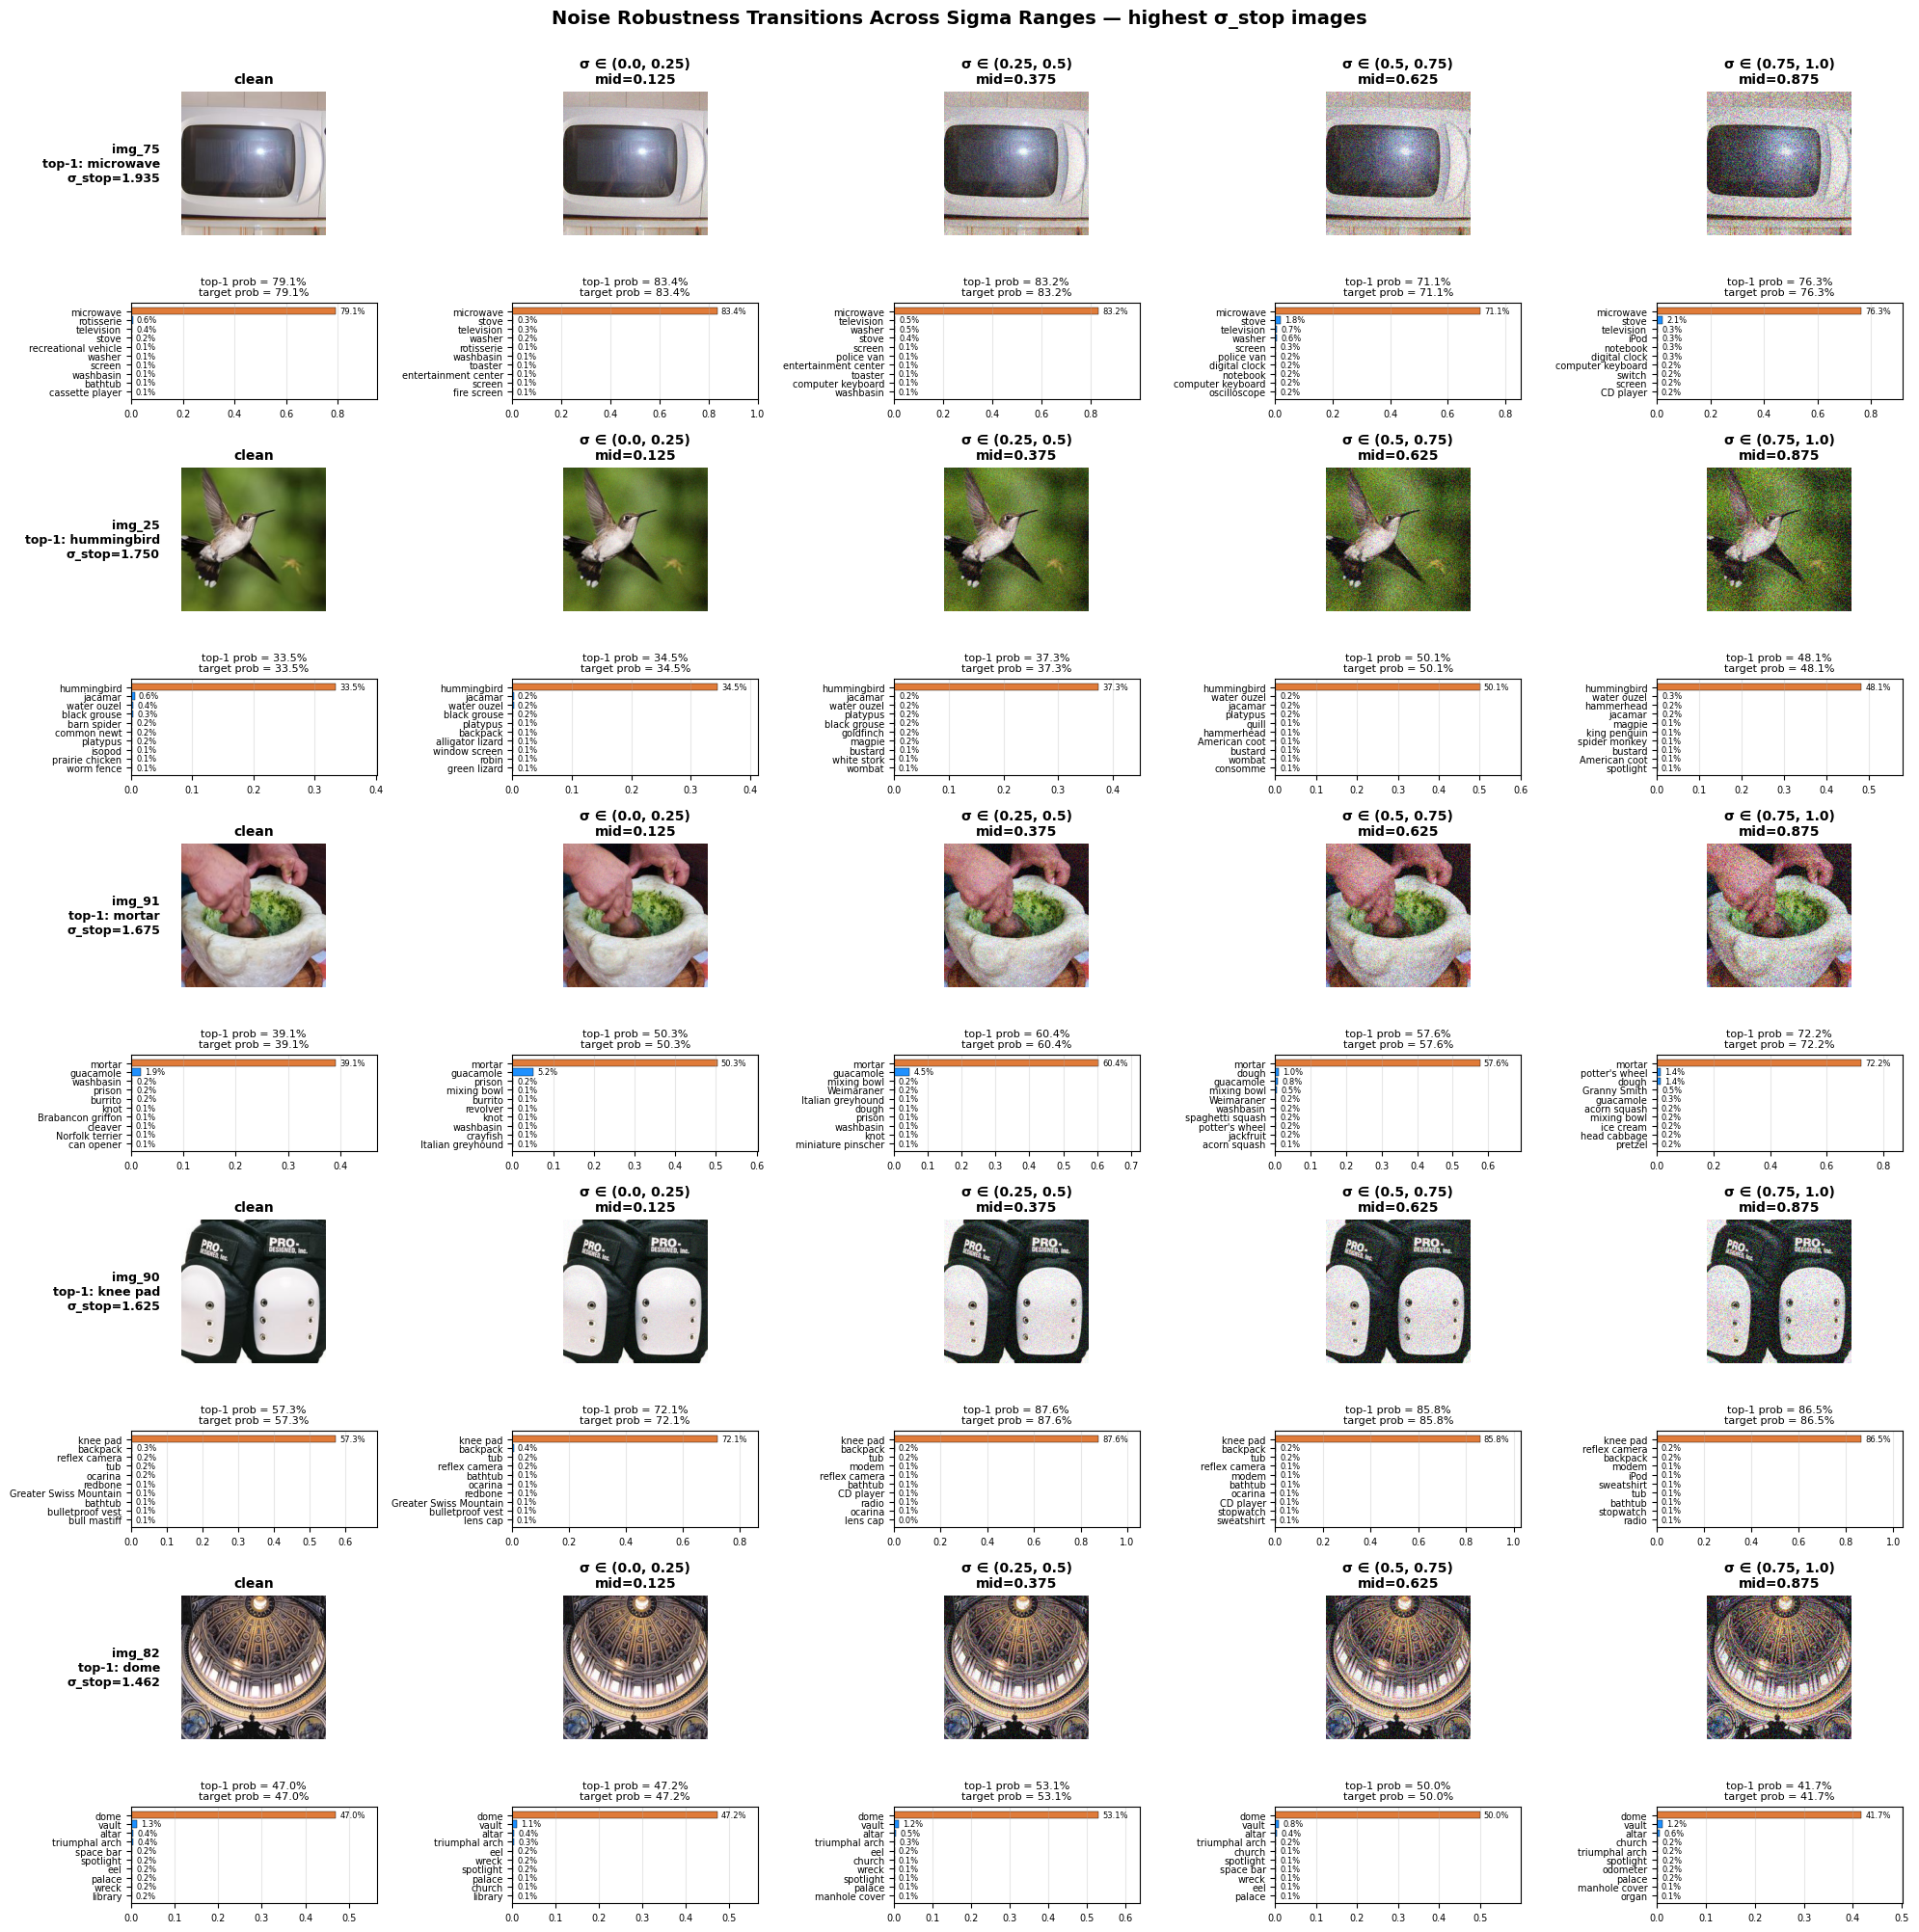

In [ ]:
# ── Noise Visualization Across Sigma Transition Bins ──────────────

import numpy as np
import torch
import matplotlib.pyplot as plt

N_VIZ = 5
TOP_K = 10
SIGMA_CAP = 1.0

SIGMA_BINS = [
    (0.00, 0.25),
    (0.25, 0.50),
    (0.50, 0.75),
    (0.75, 1.00),
]

VIZ_SIGMAS = [0.0] + [(a + b) / 2 for a, b in SIGMA_BINS]

# compute σ_stop for each eval image
sigma_pairs = []

for idx in tqdm(eval_idx, desc="computing sigma_stop"):
    r = results[idx]
    x, tgt = r["x"], r["target"]

    sf = get_sigma_final("adapt", model, x, tgt)
    sigma_pairs.append((idx, sf))

# pick highest σ_stop images
top_pairs = sorted(
    sigma_pairs,
    key=lambda t: t[1],
    reverse=True
)[:N_VIZ]

viz_indices = [idx for idx, _ in top_pairs]

n_cols = len(VIZ_SIGMAS)
n_rows = len(viz_indices)

fig, axes = plt.subplots(
    n_rows * 2,
    n_cols,
    figsize=(4 * n_cols, 4 * n_rows),
    gridspec_kw={"height_ratios": [3, 2] * n_rows}
)

if n_rows == 1:
    axes = axes.reshape(2, n_cols)

for row_i, img_i in enumerate(viz_indices):
    r = results[img_i]
    x, tgt = r["x"], r["target"]
    label_str = r["label_str"]
    fname = f"img_{img_i}"

    sigma_stop_img = dict(sigma_pairs)[img_i]

    sigma_titles = ["clean"] + [
        f"σ ∈ ({a}, {b})\nmid={((a+b)/2):.3f}"
        for a, b in SIGMA_BINS
    ]

    img_ax_row = row_i * 2
    bar_ax_row = row_i * 2 + 1

    for col_i, (sf, title) in enumerate(zip(VIZ_SIGMAS, sigma_titles)):

        with torch.no_grad():
            if sf == 0.0:
                x_noisy = x
            else:
                torch.manual_seed(42 + col_i)
                x_noisy = x + sf * torch.randn_like(x)

            probs = model(x_noisy).softmax(-1)[0]
            top_probs, top_idx = probs.topk(TOP_K)

            top_probs_np = top_probs.cpu().numpy()
            top_idx_list = top_idx.cpu().tolist()

            top_labels = [
                imagenet_labels[i][:22]
                for i in top_idx_list
            ]

            p_target = probs[tgt].item()

        img_ax = axes[img_ax_row, col_i]

        img_np = denormalize(x_noisy[0]).detach().cpu().permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)

        img_ax.imshow(img_np)
        img_ax.set_title(title, fontsize=10, fontweight="bold")
        img_ax.axis("off")

        if col_i == 0:
            img_ax.text(
                -0.15, 0.5,
                f"{fname}\ntop-1: {label_str[:22]}\nσ_stop={sigma_stop_img:.3f}",
                transform=img_ax.transAxes,
                fontsize=9,
                fontweight="bold",
                va="center",
                ha="right"
            )

        bar_ax = axes[bar_ax_row, col_i]

        colors = [
            "#E07B39" if i == tgt else "#1E90FF"
            for i in top_idx_list
        ]

        bars = bar_ax.barh(
            range(TOP_K),
            top_probs_np[::-1],
            color=colors[::-1],
            edgecolor="black",
            lw=0.3
        )

        bar_ax.set_yticks(range(TOP_K))
        bar_ax.set_yticklabels(top_labels[::-1], fontsize=7)
        bar_ax.set_xlim(0, max(top_probs_np.max() * 1.2, 0.1))
        bar_ax.tick_params(axis="x", labelsize=7)

        bar_ax.set_title(
            f"top-1 prob = {top_probs_np[0] * 100:.1f}%\n"
            f"target prob = {p_target * 100:.1f}%",
            fontsize=8
        )

        bar_ax.grid(axis="x", alpha=0.3)

        for bar, p in zip(bars, top_probs_np[::-1]):
            bar_ax.text(
                bar.get_width() + max(top_probs_np) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{p * 100:.1f}%",
                va="center",
                fontsize=6
            )

plt.suptitle(
    "Noise Robustness Transitions Across Sigma Ranges — highest σ_stop images",
    fontweight="bold",
    fontsize=14,
    y=1.00
)

plt.tight_layout()
plt.savefig("noise_sigma_transition_grid.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Qualitative Comparison: All 8 Methods Across Image Types — Pos/Neg cividis ──
import random
random.seed(42)

IMAGE_TYPE_KEYWORDS = {
    "animal":    ["dog","cat","bird","fish","snake","lizard","frog","elephant",
                  "tiger","lion","bear","fox","wolf","deer","horse","cow","sheep",
                  "monkey","ape","panda","leopard","zebra","penguin","owl","eagle",
                  "whale","shark","spider","beetle","rabbit","squirrel","goat",
                  "pig","camel","kangaroo","ostrich"],
    "vehicle":   ["car","truck","bus","train","boat","ship","airplane","bicycle",
                  "motorcycle","cab","wagon","trailer","scooter","tank","ambulance"],
    "object":    ["chair","table","lamp","bottle","cup","book","keyboard","phone",
                  "computer","clock","watch","monitor","camera","scissors",
                  "umbrella","mask","helmet","backpack","tie"],
    "food":      ["bread","pizza","cake","apple","banana","orange","broccoli",
                  "sandwich","hotdog","donut","cheese","mushroom","strawberry",
                  "lemon","ice cream"],
    "nature":    ["tree","flower","mountain","beach","lake","forest","valley",
                  "cliff","seashore","volcano","coral","alp","hill","river"],
    "structure": ["building","castle","church","tower","bridge","dome","barn",
                  "lighthouse","palace","fountain","stadium"],
}

def classify_label(label_str):
    s = label_str.lower()
    for cat, kws in IMAGE_TYPE_KEYWORDS.items():
        if any(kw in s for kw in kws): return cat
    return "other"

buckets = {cat: [] for cat in IMAGE_TYPE_KEYWORDS}; buckets["other"] = []
for idx in eval_idx:
    buckets[classify_label(results[idx]["label_str"])].append(idx)

N_PER_CATEGORY = 1
vis_idx, vis_cats = [], []
for cat in IMAGE_TYPE_KEYWORDS.keys():
    ids = buckets[cat][:]; random.shuffle(ids)
    for i in ids[:N_PER_CATEGORY]:
        vis_idx.append(i); vis_cats.append(cat)

print(f"Selected {len(vis_idx)} images across {len(set(vis_cats))} categories: {sorted(set(vis_cats))}")

KLIG_SIGMAS_VIS = ["adaptive", "σ=0.25"]
BASELINE_MS_VIS = ["IDG", "ExpGrad", "IG-zero", "Blur-IG", "SmoothGrad", "Vanilla Grad"]
N_VIS  = len(vis_idx)
N_COLS = 1 + len(KLIG_SIGMAS_VIS) + len(BASELINE_MS_VIS)

fig, axes = plt.subplots(N_VIS * 2, N_COLS,
                         figsize=(N_COLS * 2.0, N_VIS * 4.0),
                         facecolor="white")
if N_VIS == 1: axes = axes[np.newaxis, :]

def _pos_neg_pair(ax_pos, ax_neg, x, raw_attr):
    img  = np.clip(denormalize(x[0]).detach().cpu().permute(1,2,0).numpy(), 0, 1)
    gray = np.mean(img, axis=2)
    for ax, a_hw, cmap in [
        (ax_pos, raw_attr.clamp(min=0).sum(dim=0),       "cividis"),
        (ax_neg, raw_attr.clamp(max=0).abs().sum(dim=0), "cividis_r"),
    ]:
        a = a_hw.detach().cpu().numpy()
        vmax = np.percentile(a, 99); vmax = vmax if vmax > 1e-12 else 1.0
        ax.imshow(gray, cmap="gray", vmin=0, vmax=1)
        ax.imshow(np.clip(a / vmax, 0, 1), cmap=cmap, vmin=0, vmax=1, alpha=0.7)
        ax.set_xticks([]); ax.set_yticks([])

for row, (idx, cat) in enumerate(tqdm(list(zip(vis_idx, vis_cats)),
                                       desc="qual all methods")):
    r = results[idx]; x, tgt = r["x"], r["target"]
    img_np = np.clip(denormalize(x[0]).detach().cpu().permute(1,2,0).numpy(), 0, 1)
    r_pos, r_neg = row * 2, row * 2 + 1
    for ri in [r_pos, r_neg]:
        axes[ri, 0].imshow(img_np); axes[ri, 0].set_xticks([]); axes[ri, 0].set_yticks([])
    axes[r_pos, 0].set_ylabel(f"[{cat}]\n{r['label_str'][:18]}\n(+)",
                               fontsize=7, rotation=0, labelpad=65, va="center", fontweight="bold")
    axes[r_neg, 0].set_ylabel("(−)", fontsize=9, rotation=0, labelpad=65, va="center")

    for col_offset, sigma_name in enumerate(KLIG_SIGMAS_VIS):
        sf = get_sigma_final(sigma_name, model, x, tgt)
        raw = raw_klig(model, x, tgt, sf)
        _pos_neg_pair(axes[r_pos, 1 + col_offset], axes[r_neg, 1 + col_offset], x, raw)

    for col_offset, m in enumerate(BASELINE_MS_VIS):
        raw = RAW_FN[m](model, x, tgt)
        _pos_neg_pair(axes[r_pos, 1 + len(KLIG_SIGMAS_VIS) + col_offset],
                      axes[r_neg, 1 + len(KLIG_SIGMAS_VIS) + col_offset], x, raw)

axes[0, 0].set_title("Original", fontsize=9, fontweight="bold")
col_titles = [f"KL-IG ({sn})" for sn in KLIG_SIGMAS_VIS] + BASELINE_MS_VIS
for col, ttl in enumerate(col_titles, start=1):
    axes[0, col].set_title(ttl, fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig("qualitative_all_methods_by_type.png", dpi=180, bbox_inches="tight")
plt.show()

#Signed Attr

In [ ]:
# ── Signed Attribution Evaluation (KL-IG adapt only) ──

methods_signed = ["KL-IG (adapt)", "IDG", "ExpGrad", "IG-zero", "SmoothGrad", "Vanilla Grad", "Blur-IG", "Blur-IG"]

def signed_insertion(model, x, attr_map, target, n_steps=50, positive=True):
    H, W = attr_map.shape
    a = attr_map.detach().cpu().numpy().ravel()
    if positive:
        valid = np.where(a > 0)[0]
        order = valid[np.argsort(-a[valid])]
    else:
        valid = np.where(a < 0)[0]
        order = valid[np.argsort(a[valid])]
    if len(order) == 0:
        return 0.0, np.array([])

    substrate = make_blur_baseline(x)
    img = substrate.clone()
    scores = []
    pps = max(1, len(order) // n_steps)

    with torch.no_grad():
        scores.append(model(img).softmax(-1)[0, target].item())
        for s in range(1, n_steps + 1):
            e = min(s * pps, len(order))
            idx_patch = order[(s - 1) * pps:e]
            if len(idx_patch) == 0:
                scores.append(scores[-1]); continue
            hi, wi = idx_patch // W, idx_patch % W
            img[0, :, hi, wi] = x[0, :, hi, wi]
            scores.append(model(img).softmax(-1)[0, target].item())

    scores = np.array(scores)
    auc = float(np.trapz(scores, dx=1.0 / len(scores)))
    return auc, scores

def sign_agreement(attr_a, attr_b, eps=1e-8):
    a = attr_a.detach().cpu().numpy().ravel()
    b = attr_b.detach().cpu().numpy().ravel()
    valid = (np.abs(a) > eps) & (np.abs(b) > eps)
    if valid.sum() == 0:
        return 0.0
    return float((np.sign(a[valid]) == np.sign(b[valid])).mean())

sign_disc     = {m: [] for m in methods_signed}
sign_agree_ig = {m: [] for m in methods_signed}
signed_example_curves = {}

for idx in tqdm(eval_idx, desc="signed"):
    r = results[idx]
    x, tgt = r["x"], r["target"]

    # Compute all maps for this image
    sf = get_sigma_final("adapt", model, x, tgt)
    _, klig_amap = compute_klig(model, x, tgt, sf)

    amaps = {"KL-IG (adapt)": klig_amap}
    for m in ["IDG", "ExpGrad", "IG-zero", "SmoothGrad", "Vanilla Grad", "Blur-IG", "Blur-IG"]:
        amaps[m] = COMPUTE_FN[m](model, x, tgt)

    ig_map = amaps["IG-zero"]

    for m in methods_signed:
        amap = amaps[m]
        pos_auc, pos_curve = signed_insertion(model, x, amap, tgt, positive=True)
        neg_auc, neg_curve = signed_insertion(model, x, amap, tgt, positive=False)
        sign_disc[m].append(pos_auc - neg_auc)
        sign_agree_ig[m].append(sign_agreement(amap, ig_map))

        if m not in signed_example_curves and len(pos_curve) > 0 and len(neg_curve) > 0:
            signed_example_curves[m] = {
                "pos_curve": pos_curve,
                "neg_curve": neg_curve,
                "gap": pos_auc - neg_auc,
            }

# ── Print summary ──
print(f"\n{'Method':<22} {'Sign gap (↑)':>12}  {'Sign agree IG (↑)':>18}")
print("-" * 56)
for m in methods_signed:
    g = np.mean(sign_disc[m])
    a = np.mean(sign_agree_ig[m])
    print(f"{m:<22} {g:>+12.4f}  {a:>18.4f}")



signed:   0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_560/3955398168.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = float(np.trapz(scores, dx=1.0 / len(scores)))



Method                 Sign gap (↑)   Sign agree IG (↑)
--------------------------------------------------------
KL-IG (adapt)               +0.1892              0.5365
IDG                         +0.0110              0.6353
ExpGrad                     +0.0927              0.5487
IG-zero                     +0.0313              1.0000
SmoothGrad                  -0.0253              0.4982
Vanilla Grad                -0.0009              0.4886


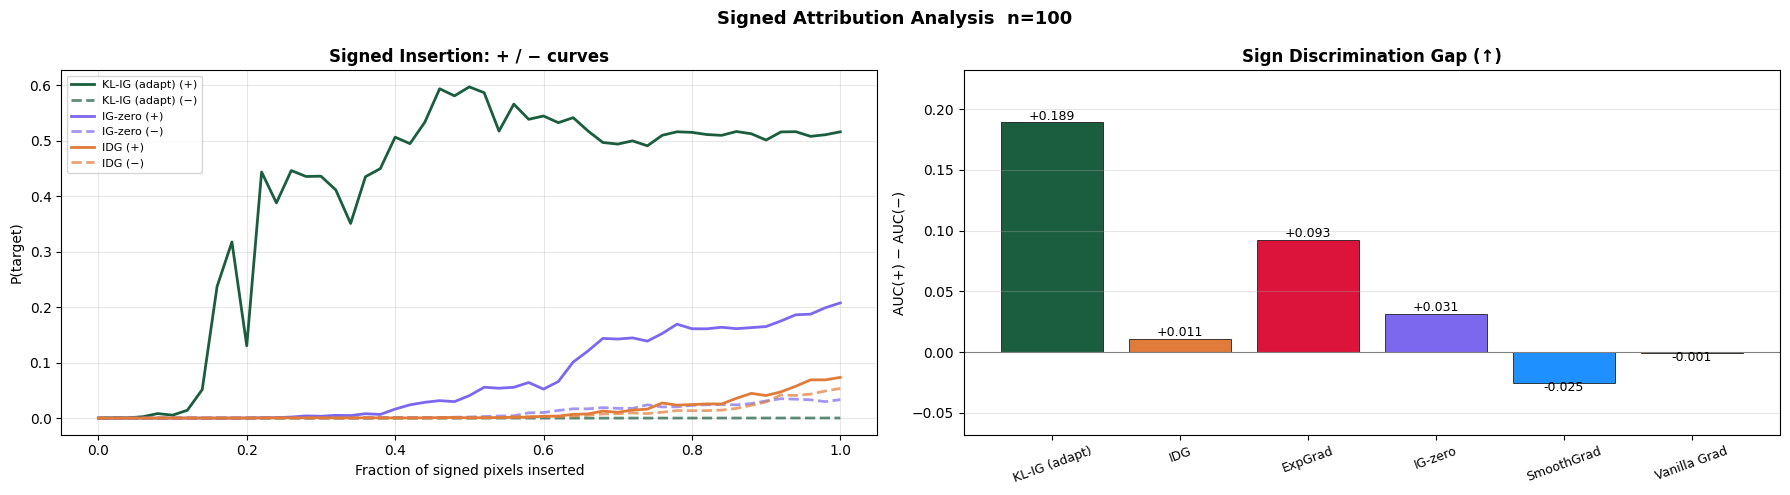

In [ ]:
# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# (a) Signed insertion curves
for m in ["KL-IG (adapt)", "IG-zero", "IDG"]:
    if m not in signed_example_curves:
        continue
    cp = signed_example_curves[m]["pos_curve"]
    cn = signed_example_curves[m]["neg_curve"]
    axes[0].plot(np.linspace(0, 1, len(cp)), cp, "-",  color=COLORS_ALL[m], lw=2, label=f"{m} (+)")
    axes[0].plot(np.linspace(0, 1, len(cn)), cn, "--", color=COLORS_ALL[m], lw=2, alpha=0.7, label=f"{m} (−)")
axes[0].set_xlabel("Fraction of signed pixels inserted")
axes[0].set_ylabel("P(target)")
axes[0].set_title("Signed Insertion: + / − curves", fontweight="bold")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# (b) AUC gap bar chart
gap_means = [np.mean(sign_disc[m]) for m in methods_signed]
x_pos = np.arange(len(methods_signed))
axes[1].bar(x_pos, gap_means, color=[COLORS_ALL[m] for m in methods_signed],
            edgecolor="black", lw=0.5)
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(methods_signed, rotation=20, fontsize=9)
axes[1].set_ylabel("AUC(+) − AUC(−)")
axes[1].set_title("Sign Discrimination Gap (↑)", fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)
gpad = max(0.01, 0.2 * (max(gap_means) - min(gap_means) or 0.05))
axes[1].set_ylim(min(0, min(gap_means) - gpad), max(0, max(gap_means) + gpad))
for xi, v in zip(x_pos, gap_means):
    axes[1].text(xi, v + (0.05 * gpad if v >= 0 else -0.15 * gpad),
                 f"{v:+.3f}", ha="center", fontsize=9)



plt.suptitle(f"Signed Attribution Analysis  n={len(eval_idx)}", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

#Ablation


In [ ]:
# ── Completeness vs MC Samples ──
# Gap  |sum(attr) − ΔE[f]|  should shrink ~ 1/√N as MC samples per step grow.

def klig_with_n_samples(model, x, target, n_samples,
                        n_steps=N_STEPS, sigma_final=None):
    if sigma_final is None:
        sigma_final = max(find_sigma_stop(model, x, target=target, tau=0.95), 1.0/256.0)
    attr = ImageAttributor(model=model, n_steps=n_steps, n_samples=n_samples,
                           sigma_final=sigma_final, device=DEVICE)
    return attr.attribute(x, target=target, show_progress=False)


def output_diff_reference(model, x, target, sigma_final, n_mc=200):
    """E[logit(x + sigma*eps)[target]] - E[logit(z)[target]]  where z ~ N(0, I).
    NOTE: logit space (no softmax) to match KL-IG's objective in integrator.py.
    """
    with torch.no_grad():
        eps = torch.randn(n_mc, *x.squeeze(0).shape, device=x.device)
        x_final = x + sigma_final * eps
        f_final = model(x_final)[:, target].mean().item()
        z = torch.randn(n_mc, *x.squeeze(0).shape, device=x.device)
        f_start = model(z)[:, target].mean().item()
    return f_final - f_start


N_SAMPLES_SWEEP = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
N_TRIALS = 5
N_COMP_IMGS = min(20, len(eval_idx))   # subset for compute budget
comp_idx = eval_idx[:N_COMP_IMGS]

gap_matrix = np.zeros((len(comp_idx), len(N_SAMPLES_SWEEP), N_TRIALS))
sum_matrix = np.zeros_like(gap_matrix)
ref_vec    = np.zeros(len(comp_idx))

for i, idx in enumerate(tqdm(comp_idx, desc="comp vs MC")):
    r = results[idx]
    x, t = r["x"], r["target"]
    sigma_final = max(find_sigma_stop(model, x, target=t, tau=0.95), 1.0/256.0)
    ref = output_diff_reference(model, x, t, sigma_final, n_mc=300)
    ref_vec[i] = ref
    for j, ns in enumerate(N_SAMPLES_SWEEP):
        for k in range(N_TRIALS):
            kr = klig_with_n_samples(model, x, t, n_samples=ns,
                                     n_steps=N_STEPS, sigma_final=sigma_final)
            s = float(kr._r.completeness_check())
            sum_matrix[i, j, k] = s
            gap_matrix[i, j, k] = abs(s - ref)

mean_gap = gap_matrix.mean(axis=(0, 2))
std_gap  = gap_matrix.std(axis=(0, 2))



comp vs MC:   0%|          | 0/20 [00:07<?, ?it/s]


KeyboardInterrupt: 

NameError: name 'mean_gap' is not defined

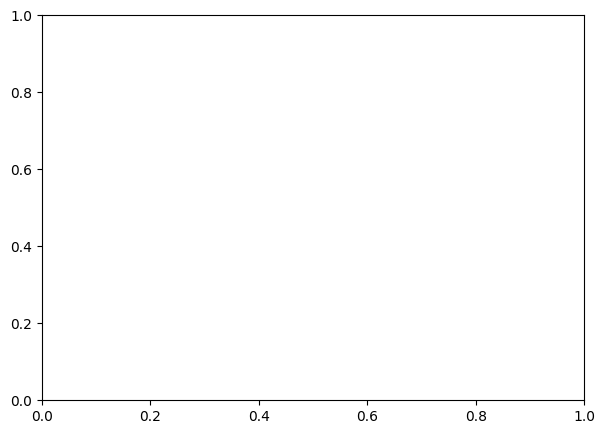

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5), facecolor="white")
ax.plot(N_SAMPLES_SWEEP, mean_gap, "o-",
        color=COLORS_ALL["KL-IG (adapt)"], lw=2, label="KL-IG gap")

if mean_gap[0] > 0:
    ref_line = mean_gap[0] * np.sqrt(N_SAMPLES_SWEEP[0] / np.array(N_SAMPLES_SWEEP))
    ax.plot(N_SAMPLES_SWEEP, ref_line, "k--", alpha=0.5, label=r"$1/\sqrt{N}$ reference")

ax.set_xlabel("N_SAMPLES (MC)", fontsize=11)
ax.set_ylabel(r"$|\Sigma\,\mathrm{attr} - \Delta\mathbb{E}[f]|$", fontsize=11)
ax.set_title(f"KL-IG Completeness gap vs MC samples  ({N_TRIALS} trials/img, n={len(comp_idx)})",
             fontweight="bold", fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("completeness_vs_mc.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nN_SAMPLES -> mean |gap| (averaged over images + trials)")
for ns, g, s in zip(N_SAMPLES_SWEEP, mean_gap, std_gap):
    print(f"  N={ns:3d}: {g:.5f} ± {s:.5f}")
print(f"\nImprovement factor: {mean_gap[0] / (mean_gap[-1] + 1e-12):.2f}×")

In [ ]:
# ── Ablation A: N_STEPS sweep — Completeness gap + runtime ──
import time

N_STEPS_SWEEP = [4, 8, 16, 32, 64, 128]
N_ABL_IMGS = min(20, len(eval_idx))
abl_idx = eval_idx[:N_ABL_IMGS]

def klig_with_steps(model, x, target, n_steps, sigma_final):
    attr = ImageAttributor(model=model, n_steps=n_steps, n_samples=N_SAMPLES,
                           sigma_final=sigma_final, device=DEVICE)
    return attr.attribute(x, target=target, show_progress=False)

def output_diff_reference(model, x, target, sigma_final, n_mc=200):
    """E[logit(x+σε)] - E[logit(z)]  — logit space, no softmax."""
    with torch.no_grad():
        x0 = x.squeeze(0)
        eps = torch.randn(n_mc, *x0.shape, device=x.device)
        f_final = model(x0.unsqueeze(0) + sigma_final * eps)[:, target].mean().item()
        z = torch.randn(n_mc, *x0.shape, device=x.device)
        f_start = model(z)[:, target].mean().item()
    return f_final - f_start

gap_by_steps  = {n: [] for n in N_STEPS_SWEEP}
time_by_steps = {n: [] for n in N_STEPS_SWEEP}

for idx in tqdm(abl_idx, desc="N_STEPS sweep"):
    r = results[idx]
    x, tgt = r["x"], r["target"]
    sigma_final = max(find_sigma_stop(model, x, target=tgt, tau=0.95), 1.0/256.0)
    ref = output_diff_reference(model, x, tgt, sigma_final, n_mc=200)

    for n in N_STEPS_SWEEP:
        t0 = time.perf_counter()
        kr = klig_with_steps(model, x, tgt, n_steps=n, sigma_final=sigma_final)
        dt = time.perf_counter() - t0
        gap = abs(float(kr._r.completeness_check()) - ref)
        gap_by_steps[n].append(gap)
        time_by_steps[n].append(dt)

def _mstd(d):
    return (np.array([np.mean(d[n]) for n in N_STEPS_SWEEP]),
            np.array([np.std(d[n])  for n in N_STEPS_SWEEP]))

gap_m, gap_s = _mstd(gap_by_steps)
tim_m, tim_s = _mstd(time_by_steps)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor="white")
color = COLORS_ALL["KL-IG (adapt)"]

axes[0].plot(N_STEPS_SWEEP, gap_m, "o-", color=color, lw=2)
axes[0].fill_between(N_STEPS_SWEEP, gap_m - gap_s, gap_m + gap_s, color=color, alpha=0.15)
axes[0].set_xlabel("N_STEPS")
axes[0].set_ylabel(r"$|\Sigma\,\mathrm{attr} - \Delta\mathbb{E}[f]|$")
axes[0].set_title("Completeness gap (↓)", fontweight="bold")

axes[1].plot(N_STEPS_SWEEP, tim_m, "o-", color=color, lw=2)
axes[1].fill_between(N_STEPS_SWEEP, tim_m - tim_s, tim_m + tim_s, color=color, alpha=0.15)
axes[1].set_xlabel("N_STEPS")
axes[1].set_ylabel("Runtime (s/image)")
axes[1].set_title("Runtime", fontweight="bold")

for a in axes:
    a.grid(alpha=0.3)
    a.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"KL-IG Ablation: N_STEPS  (n={len(abl_idx)} images)",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("ablation_n_steps.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nN_STEPS   gap                sec")
for i, n in enumerate(N_STEPS_SWEEP):
    print(f"  {n:4d}    {gap_m[i]:.4f}±{gap_s[i]:.4f}     {tim_m[i]:.2f}±{tim_s[i]:.2f}")

In [ ]:
# ════════════════════════════════════════════════════════════════════
# Completeness Gap — end-to-end
# ════════════════════════════════════════════════════════════════════
SIGMA_FIXED  = [0, 1/256, 0.1, 0.25, 0.5, 1.0, 2.0]
SIGMA_LABELS = ["σ=0", "σ=1/256", "σ=0.1", "σ=0.25", "σ=0.5", "σ=1.0", "σ=2.0", "σ_adapt"]
ALL_KEYS     = SIGMA_FIXED + ["adaptive"]

# Color per σ value (viridis ramp + red for adaptive)
cmap_vals = plt.cm.viridis(np.linspace(0, 0.85, len(SIGMA_FIXED)))
COLORS_ALL = {s: cmap_vals[i] for i, s in enumerate(SIGMA_FIXED)}
COLORS_ALL["adaptive"] = "#DC143C"

def get_attr(model, x, target, sigma_final):
    sf = max(sigma_final, 1e-7)
    attr = ImageAttributor(model=model, n_steps=N_STEPS, n_samples=N_SAMPLES,
                           sigma_final=sf, device=DEVICE)
    res = attr.attribute(x, target=target, show_progress=False)
    return res, res.attr_map("absmax")

def output_diff_reference(model, x, target, sigma_final, n_mc=200):
    """E[logit(x + σε)] − E[logit(z)]  with z ~ N(0,I).  Logit space, no softmax."""
    sf = max(sigma_final, 1e-7)
    with torch.no_grad():
        eps = torch.randn(n_mc, *x.squeeze(0).shape, device=x.device)
        f_final = model(x + sf * eps)[:, target].mean().item()
        f_start = model(torch.randn(n_mc, *x.squeeze(0).shape, device=x.device))[:, target].mean().item()
    return f_final - f_start


# ── Compute gap for every σ on every eval image ──
d_gap = {k: [] for k in ALL_KEYS}

for idx in tqdm(eval_idx, desc="completeness gap"):
    r = results[idx]
    x, tgt = r["x"], r["target"]

    sigma_adapt = max(find_sigma_stop(model, x, target=tgt, tau=0.95), 1.0/256.0)
    pairs = [(sf, sf) for sf in SIGMA_FIXED] + [("adaptive", sigma_adapt)]

    for key, sf in pairs:
        res, _ = get_attr(model, x, tgt, sf)
        ref    = output_diff_reference(model, x, tgt, sf)
        gap    = abs(float(res._r.completeness_check()) - ref)
        d_gap[key].append(gap)


# ── Plot ──
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
means = [np.mean(d_gap[k]) for k in ALL_KEYS]
stds  = [np.std(d_gap[k])  for k in ALL_KEYS]

bars = ax.bar(SIGMA_LABELS, means, yerr=stds, capsize=4,
              color=[COLORS_ALL[k] for k in ALL_KEYS],
              edgecolor="black", lw=0.5, alpha=0.85)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{m:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("|Σ attr − ΔE[f]|", fontsize=11)
ax.set_xlabel("σ_final", fontsize=11)
ax.set_title(f"Completeness Gap across σ values (↓ = better)  n={len(eval_idx)}",
             fontweight="bold", fontsize=12)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("completeness_gap_sigma.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Print summary ──
print(f"\n{'σ_final':>10s}  {'gap (mean ± std)':>20s}")
print("-" * 34)
for k, label in zip(ALL_KEYS, SIGMA_LABELS):
    print(f"{label:>10s}  {np.mean(d_gap[k]):8.4f} ± {np.std(d_gap[k]):.4f}")

completeness gap:  60%|██████    | 60/100 [07:10<04:46,  7.17s/it]

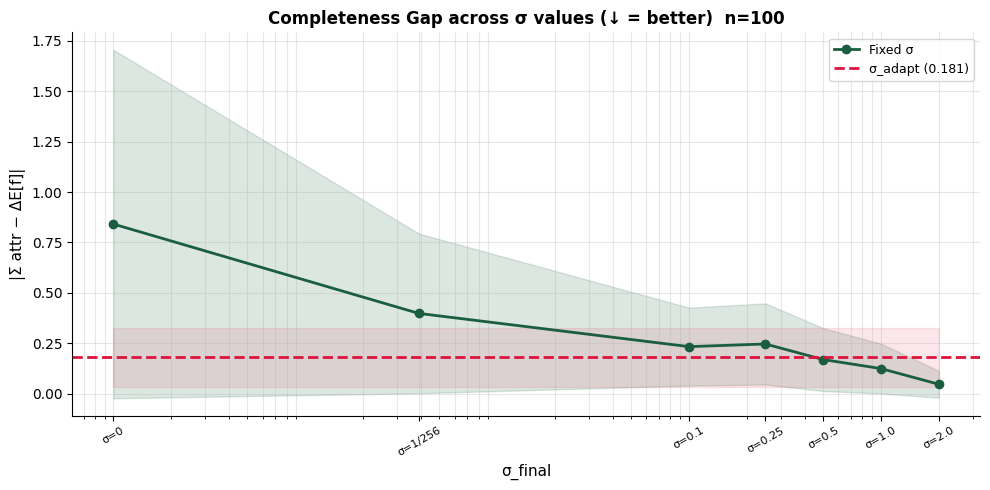


   σ_final      gap (mean ± std)
----------------------------------
       σ=0    0.8414 ± 0.8629
   σ=1/256    0.3989 ± 0.3954
     σ=0.1    0.2344 ± 0.1929
    σ=0.25    0.2475 ± 0.2010
     σ=0.5    0.1704 ± 0.1558
     σ=1.0    0.1257 ± 0.1233
     σ=2.0    0.0481 ± 0.0665
   σ_adapt    0.1813 ± 0.1455


In [ ]:
# ── Plot ──
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
means = [np.mean(d_gap[k]) for k in ALL_KEYS]
stds  = [np.std(d_gap[k])  for k in ALL_KEYS]

# numeric x positions for the fixed sigmas, skip adaptive on curve
sigma_numeric = [k if k != 0 else 1e-4 for k in SIGMA_FIXED]  # avoid log(0)

ax.plot(sigma_numeric, means[:-1], "o-", color="#1B5E3F", lw=2, ms=6,
        label="Fixed σ")
ax.fill_between(sigma_numeric,
                np.array(means[:-1]) - np.array(stds[:-1]),
                np.array(means[:-1]) + np.array(stds[:-1]),
                color="#1B5E3F", alpha=0.15)

# adaptive as a horizontal dashed line
ax.axhline(means[-1], color="#DC143C", ls="--", lw=2, label=f"σ_adapt ({means[-1]:.3f})")
ax.fill_between(sigma_numeric,
                means[-1] - stds[-1], means[-1] + stds[-1],
                color="#DC143C", alpha=0.1)

ax.set_xscale("log")
ax.set_xlabel("σ_final", fontsize=11)
ax.set_ylabel("|Σ attr − ΔE[f]|", fontsize=11)
ax.set_title(f"Completeness Gap across σ values (↓ = better)  n={len(eval_idx)}",
             fontweight="bold", fontsize=12)
ax.set_xticks(sigma_numeric)
ax.set_xticklabels(SIGMA_LABELS[:-1], rotation=30, fontsize=8)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("completeness_gap_sigma.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print summary ──
print(f"\n{'σ_final':>10s}  {'gap (mean ± std)':>20s}")
print("-" * 34)
for k, label in zip(ALL_KEYS, SIGMA_LABELS):
    print(f"{label:>10s}  {np.mean(d_gap[k]):8.4f} ± {np.std(d_gap[k]):.4f}")